# P0480 PLMN Isolation Forest Anomaly Detection

`p0480_zscore_anomaly.ipynb`와 동일한 데이터 소스를 사용하여, **P0480** PLMN의 전체 시계열에 대해 Isolation Forest 기반 이상 탐지를 수행합니다.

- **방법**: 각 시점의 모든 메트릭 벡터에 대해 Isolation Forest를 학습하고, anomaly로 판정된 시점의 **모든 feature 값**을 빨간 점으로 표시
- **결과 저장**: CSV만 저장 (이미지 저장 없음)

In [12]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", None)

TARGET_PLMN = "P0480"
CONTAMINATION = 0.01
RANDOM_STATE = 42
DATA_DIR = "../data"
SAVE_DIR = "../results"

## 1. 데이터 로드 (P0480만)

In [13]:
csv_files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".csv"))

df_list = []
for file in csv_files:
    path = os.path.join(DATA_DIR, file)
    temp_df = pd.read_csv(path)
    temp_df = temp_df[temp_df["PLMN"] == TARGET_PLMN]
    if not temp_df.empty:
        df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values("time").reset_index(drop=True)
df["time"] = pd.to_datetime(df["time"])

metric_cols = [c for c in df.columns if c not in ("time", "PLMN")]

print(f"PLMN: {TARGET_PLMN}")
print(f"기간: {df['time'].min()} ~ {df['time'].max()}")
print(f"행 수: {len(df):,}, 메트릭 수: {len(metric_cols)}")
df.head()

PLMN: P0480
기간: 2026-04-29 15:00:00+00:00 ~ 2026-06-09 14:55:00+00:00
행 수: 11,805, 메트릭 수: 46


,time,PLMN,M971,M658,M696,M855,M162,M037,M430,M185,M965,M874,M843,M494,M972,M779,M474,M265,M164,M899,M348,M204,M520,M392,M318,M736,M516,M336,M786,M378,M529,M104,M688,M991,M767,M609,M719,M904,M452,M362,M490,M841,M419,M618,M475,M238,M029,M610
0,2026-04-29 15:00:00+00:00,P0480,3898,26,1085,0,0,0,0,45,15,149,0,0,0,0,0,2,0,9,0,0,2589,0,0.0,0,0,0,24,26,0,0,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0
1,2026-04-29 15:05:00+00:00,P0480,4014,32,1095,0,0,0,0,43,4,153,0,0,0,0,0,6,0,9,0,0,2701,0,0.0,0,1,0,26,32,0,1,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0
2,2026-04-29 15:10:00+00:00,P0480,3965,27,1114,0,0,0,0,44,28,146,0,0,0,0,0,2,0,8,0,0,2609,0,0.0,0,1,0,23,27,0,0,0,0,0,9,0,2,0,0,0,0,0,0,0,0,0,0
3,2026-04-29 15:15:00+00:00,P0480,3839,22,982,0,0,0,0,43,3,165,0,0,0,0,0,4,0,4,0,0,2620,0,0.0,0,0,0,18,22,0,1,0,0,0,10,0,3,0,0,0,0,0,0,0,0,0,0
4,2026-04-29 15:20:00+00:00,P0480,3929,20,1101,0,0,0,0,47,15,168,0,0,0,6,0,3,0,5,0,0,2589,0,0.0,0,0,0,24,20,1,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0


## 2. Isolation Forest 이상 탐지

In [14]:
X = df[metric_cols].fillna(0).to_numpy()

model = IsolationForest(
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_estimators=100,
)
pred = model.fit_predict(X)
scores = model.decision_function(X)

df["if_pred"] = pred
df["if_score"] = scores
df["is_anomaly"] = pred == -1

anomaly_mask = pd.DataFrame(False, index=df.index, columns=metric_cols)
anomaly_idx = df.index[df["is_anomaly"]]
anomaly_mask.loc[anomaly_idx, :] = True

df["anomaly_count"] = anomaly_mask.sum(axis=1)

anomaly_summary = (
    anomaly_mask.sum()
    .reset_index(name="anomaly_count")
    .rename(columns={"index": "metric"})
    .sort_values("anomaly_count", ascending=False)
)

print(f"anomaly 시점 수: {df['is_anomaly'].sum():,} / {len(df):,}")
print(f"anomaly 비율: {df['is_anomaly'].mean():.2%}")
print(f"contamination: {CONTAMINATION}")
anomaly_summary.head(10)

anomaly 시점 수: 119 / 11,805
anomaly 비율: 1.01%
contamination: 0.01


,metric,anomaly_count
0,M971,119
34,M719,119
25,M336,119
26,M786,119
27,M378,119
28,M529,119
29,M104,119
30,M688,119
31,M991,119
32,M767,119


## 3. 전체 시계열 시각화 (anomaly 표시)

모든 메트릭을 한 그래프에 그린 뒤, **anomaly로 판단된 시점의 각 feature 값**을 빨간 점으로 표시합니다.

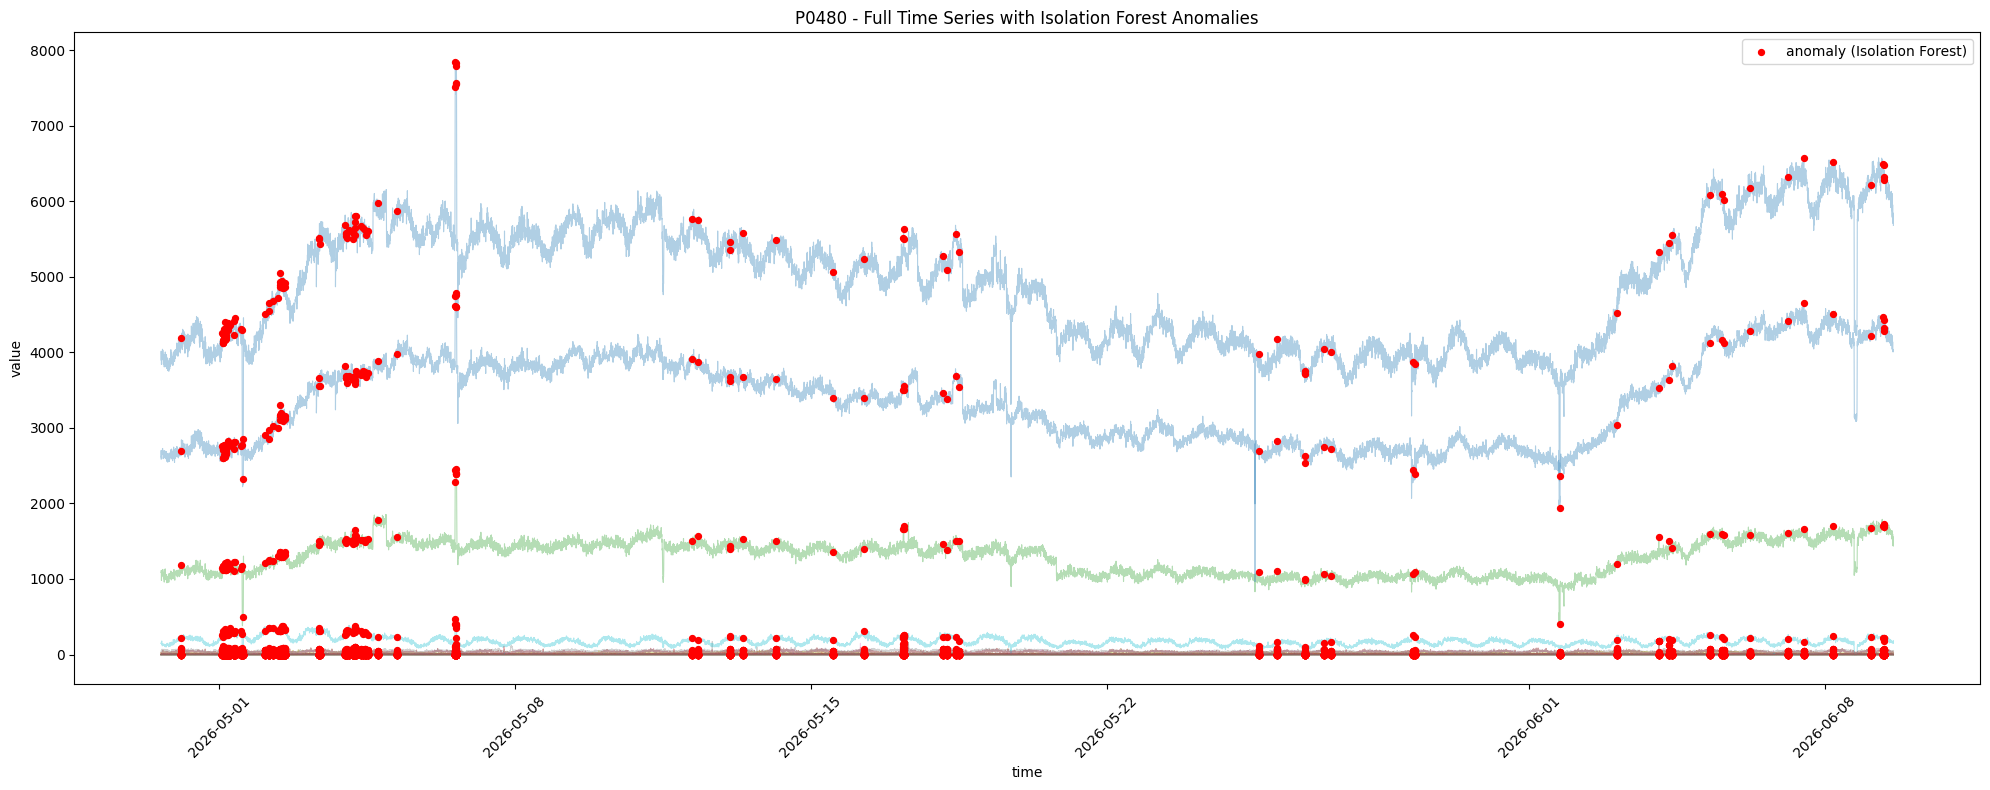

In [15]:
fig, ax = plt.subplots(figsize=(20, 8))

anomaly_labeled = False
for col in metric_cols:
    ax.plot(df["time"], df[col], alpha=0.35, linewidth=0.8)

    idx = df.index[anomaly_mask[col]]
    if len(idx) == 0:
        continue

    ax.scatter(
        df.loc[idx, "time"],
        df.loc[idx, col],
        color="red",
        s=18,
        zorder=5,
        label="anomaly (Isolation Forest)" if not anomaly_labeled else None,
    )
    anomaly_labeled = True

ax.set_title(f"{TARGET_PLMN} - Full Time Series with Isolation Forest Anomalies")
ax.set_xlabel("time")
ax.set_ylabel("value")
if anomaly_labeled:
    ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. 메트릭별 시계열 + anomaly 상세 플롯

anomaly가 한 번이라도 발생한 메트릭에 대해 개별 시계열을 그립니다.

anomaly가 있는 메트릭 수: 46


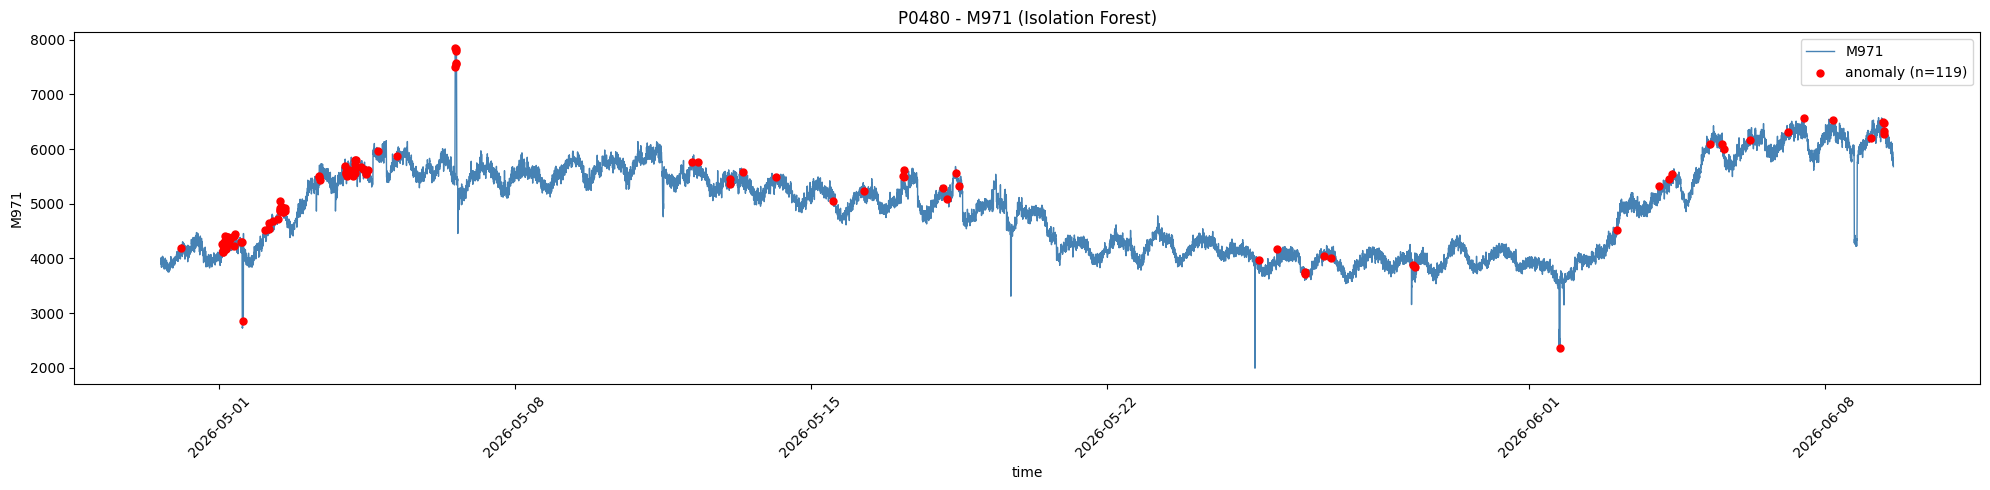

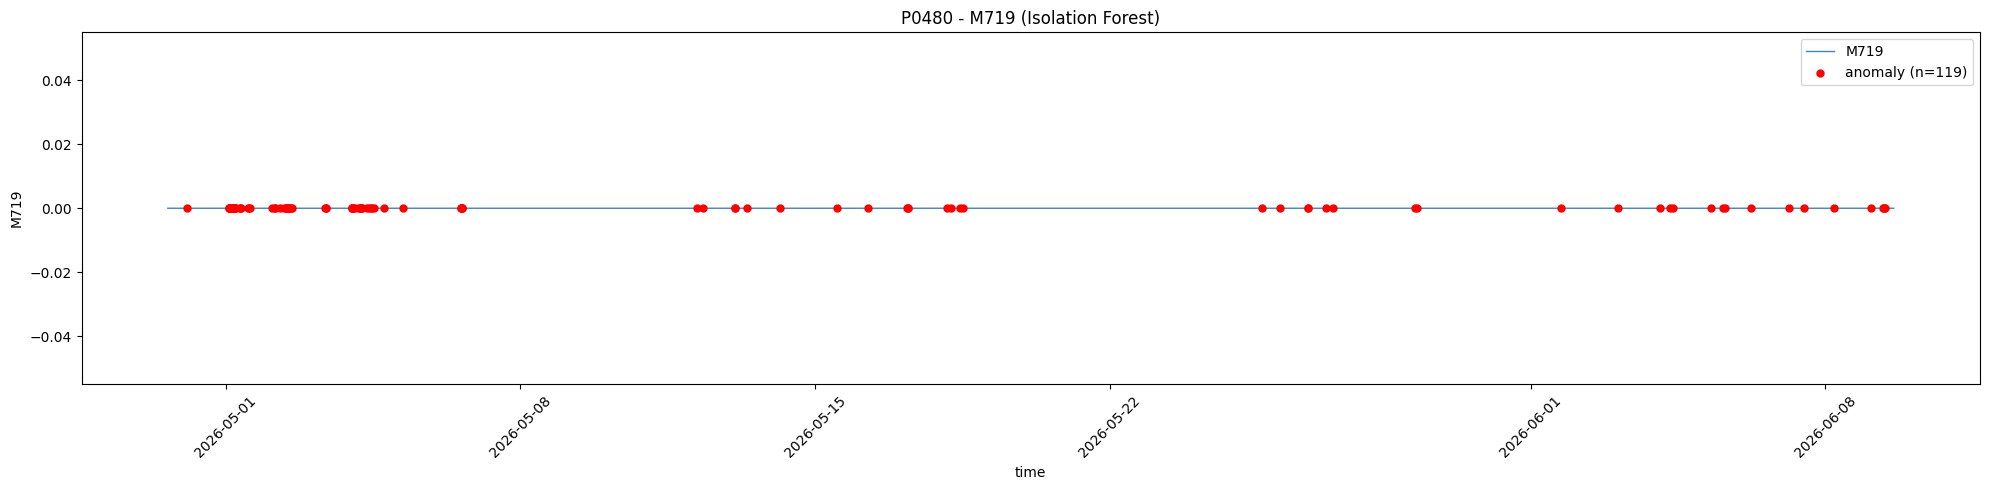

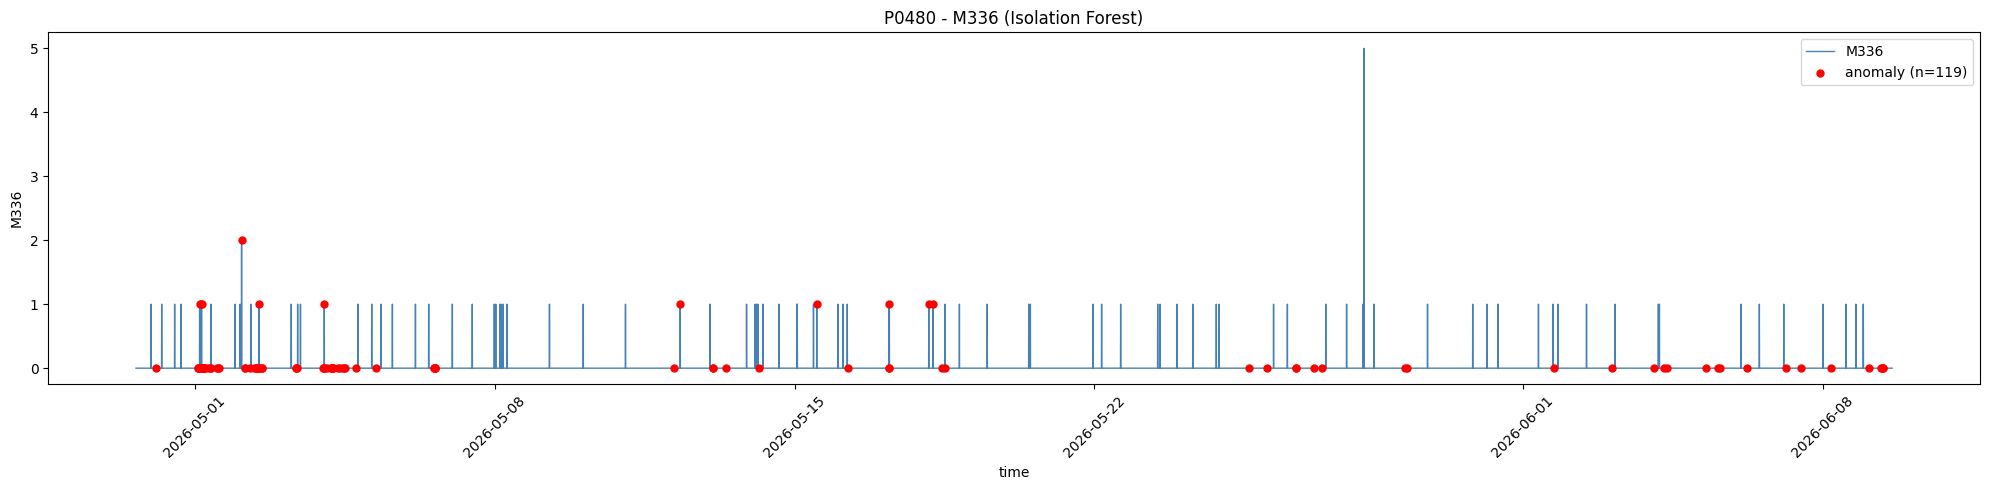

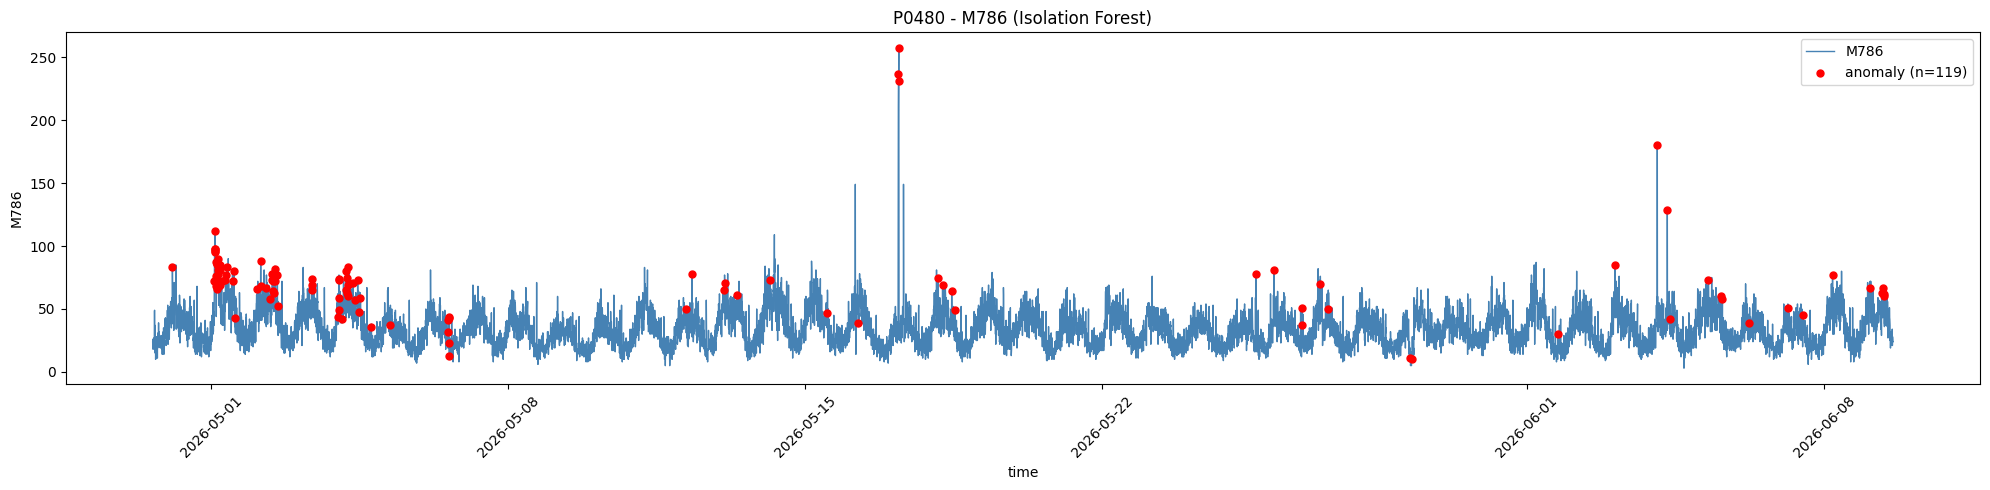

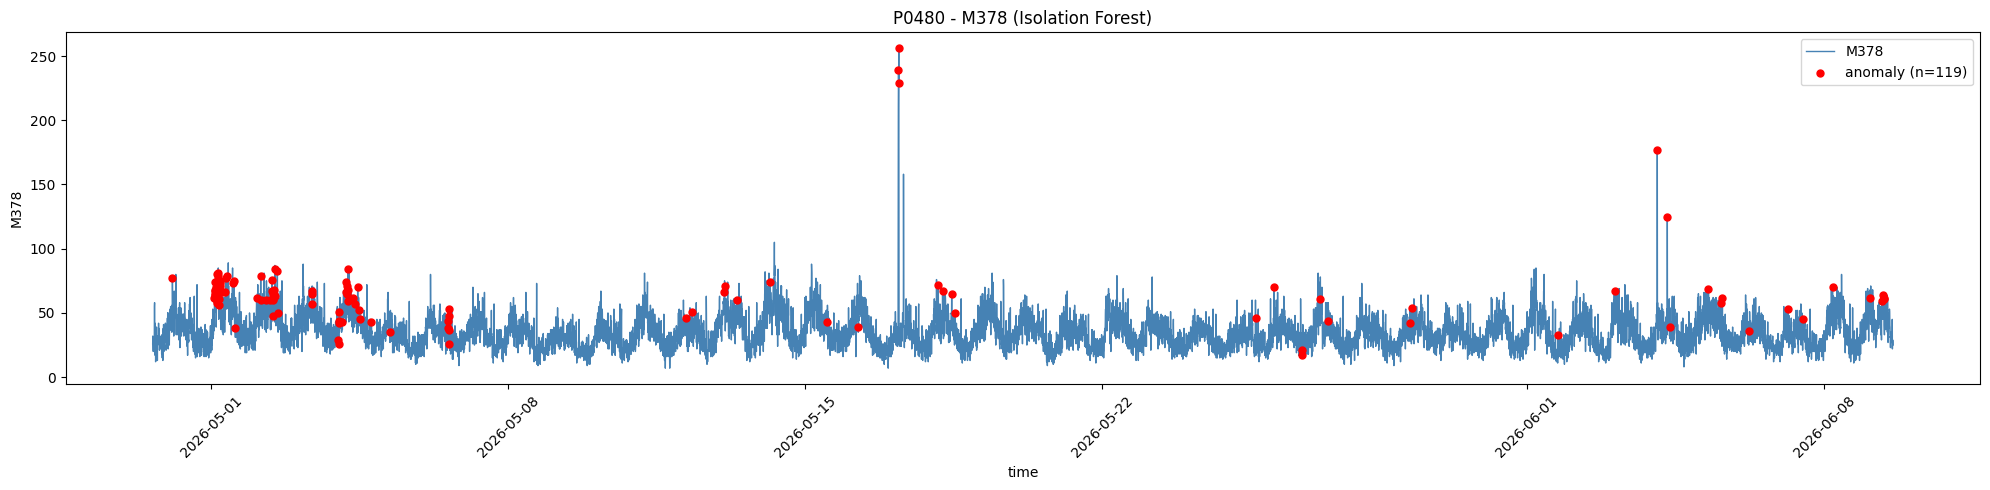

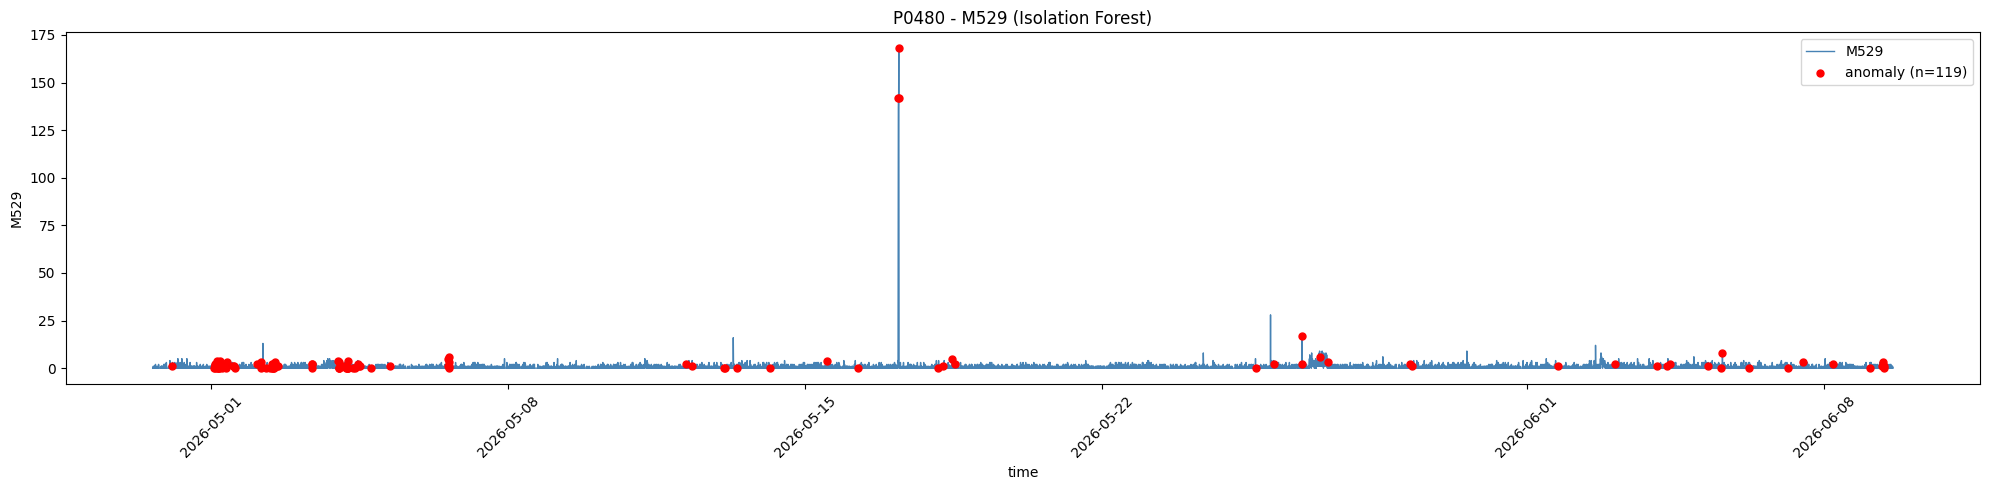

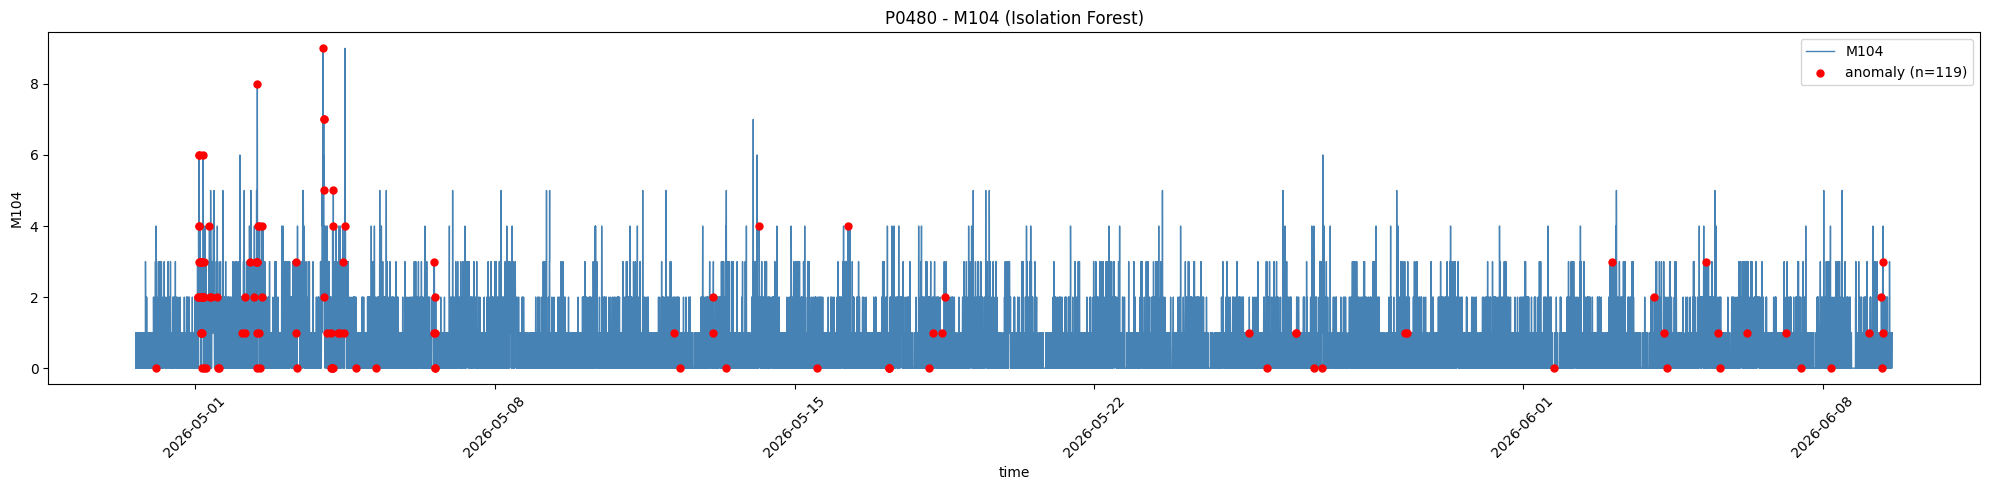

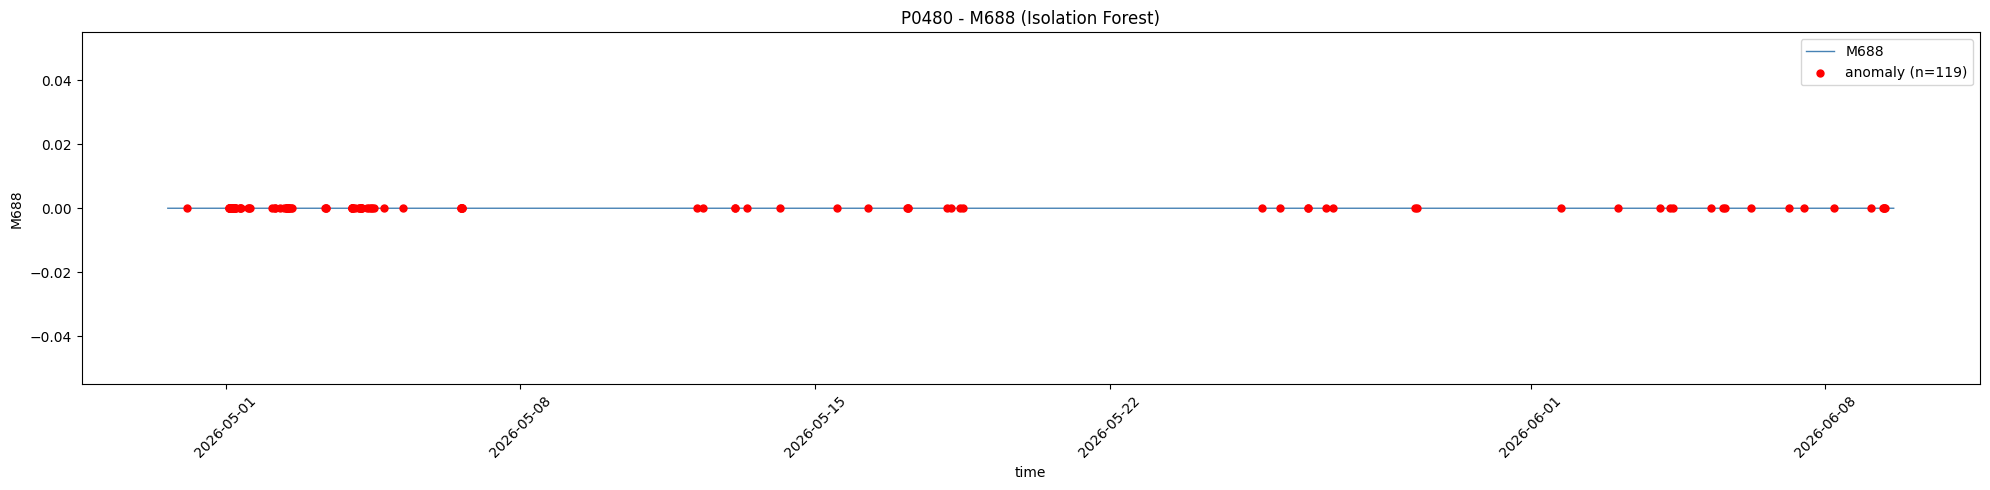

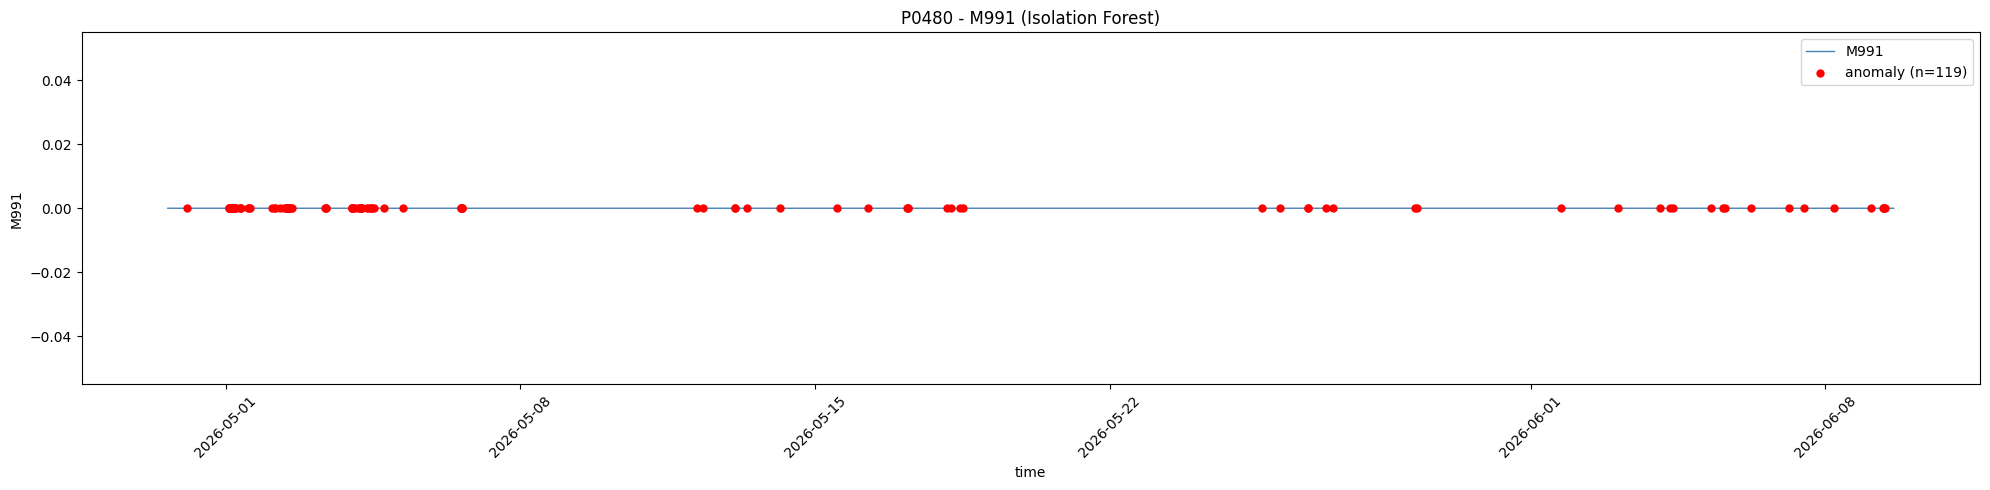

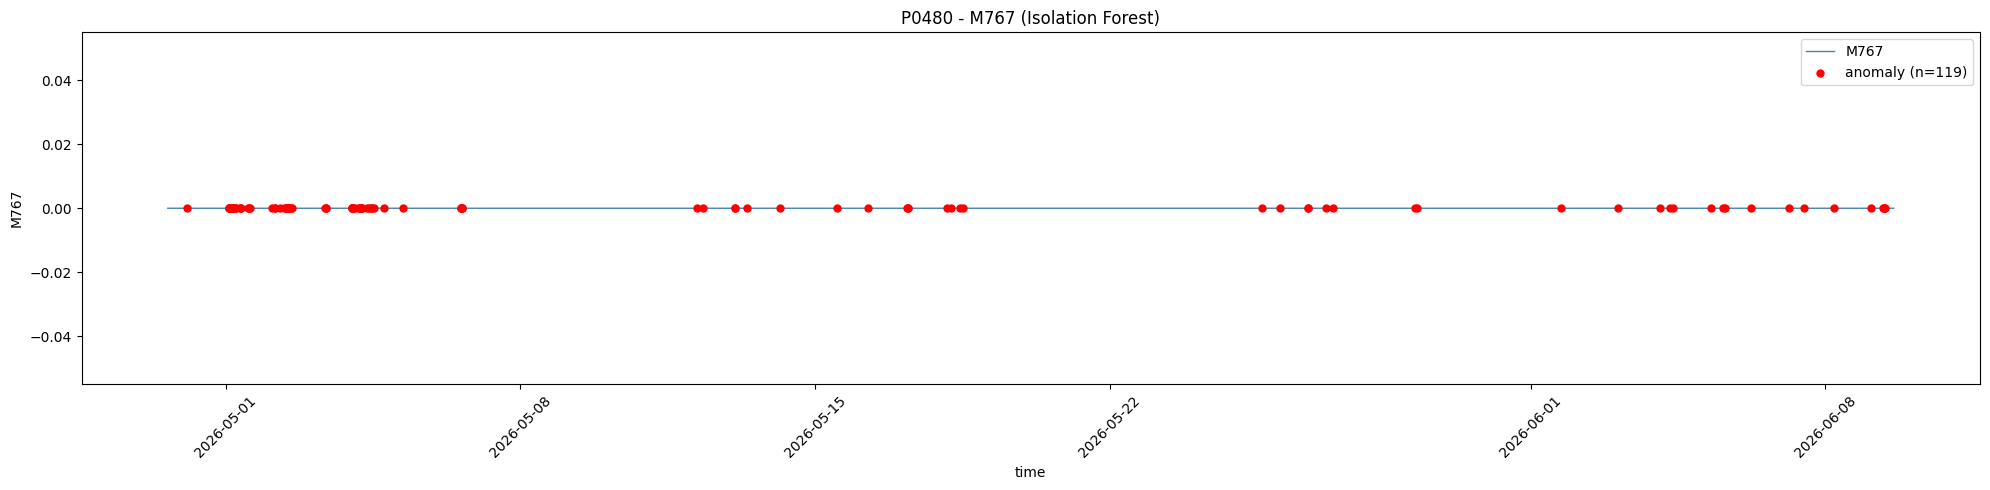

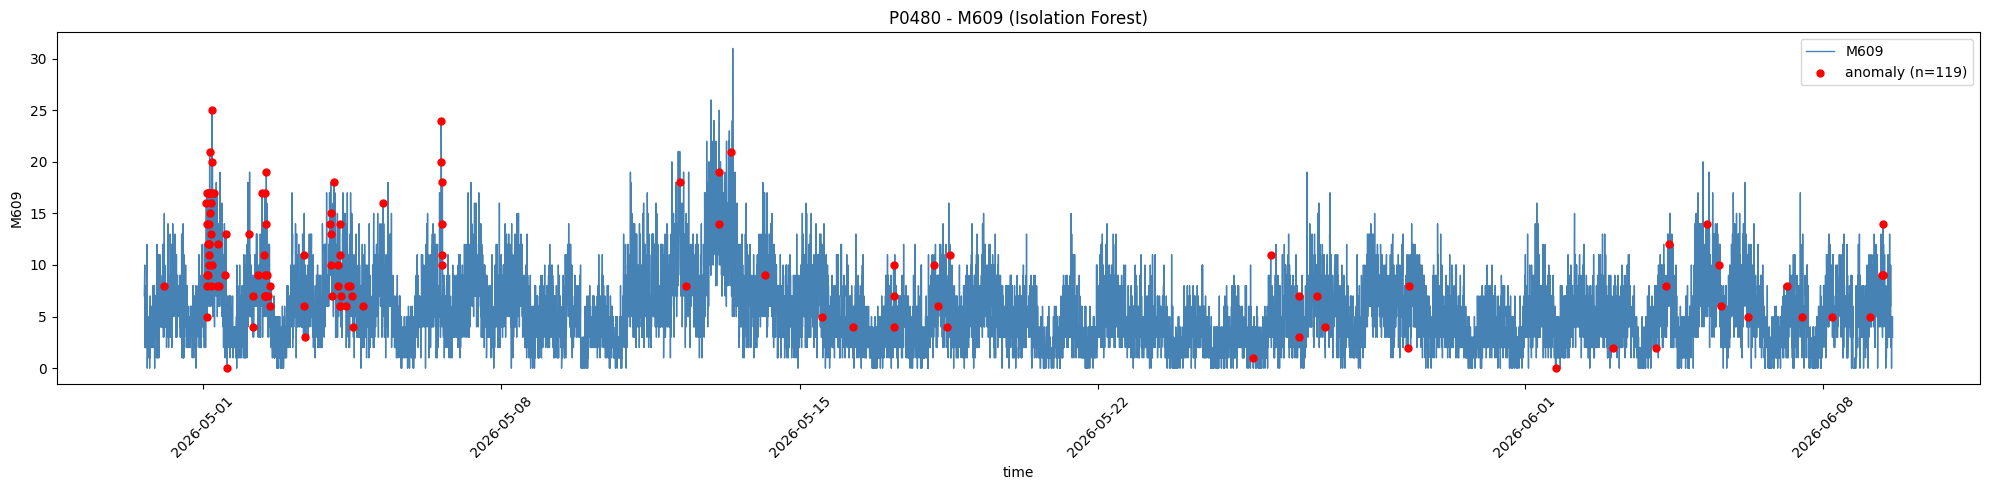

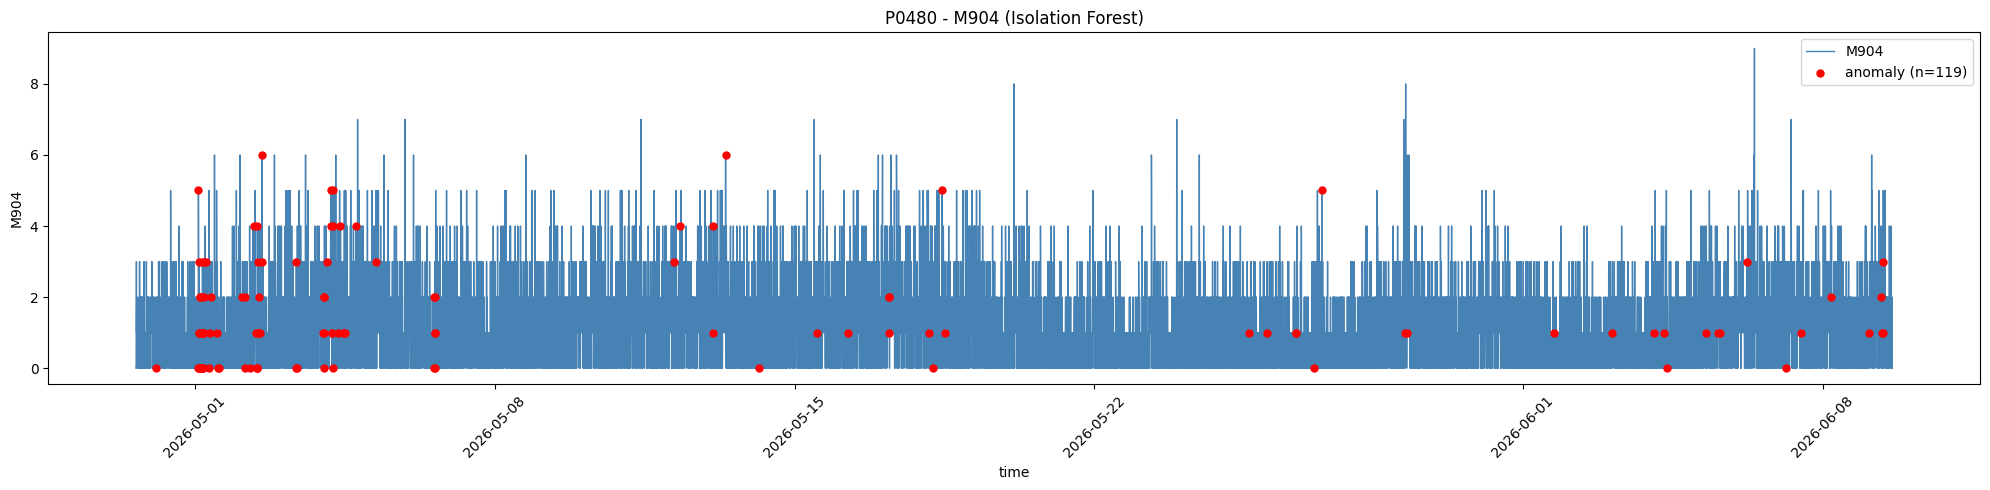

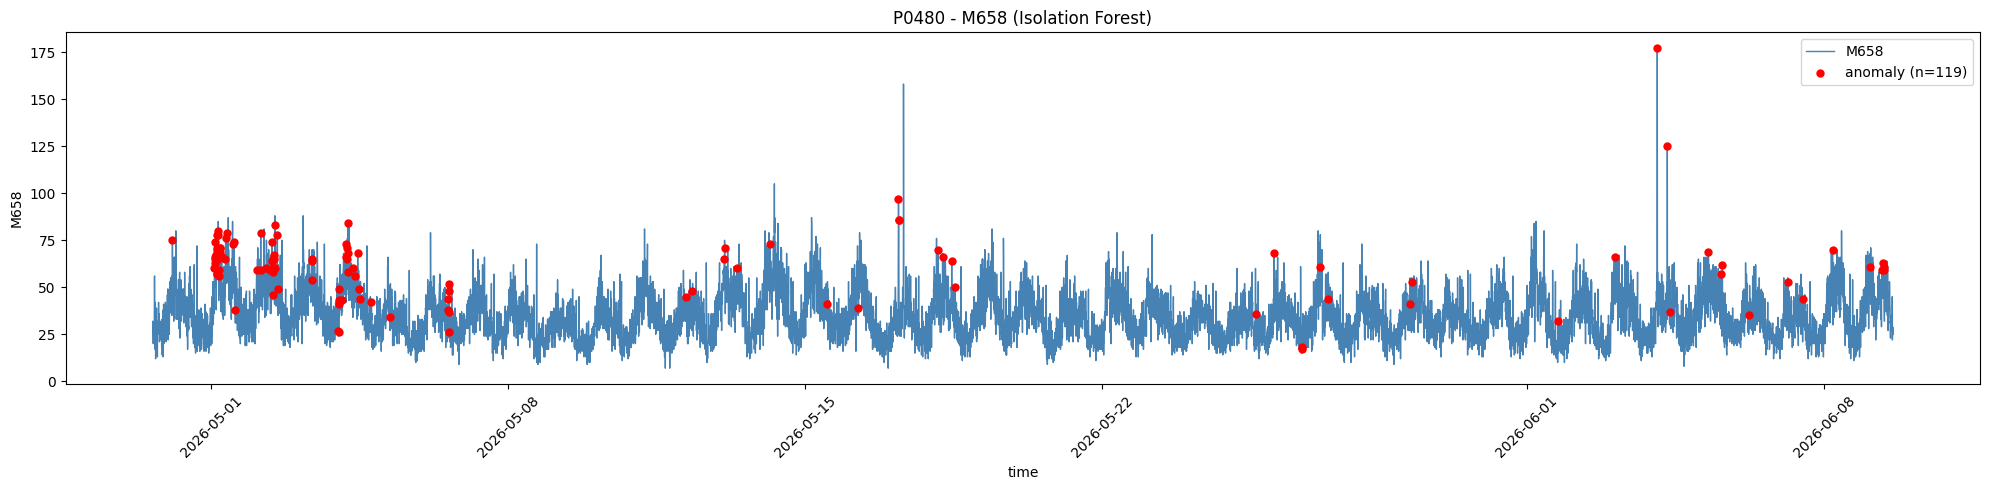

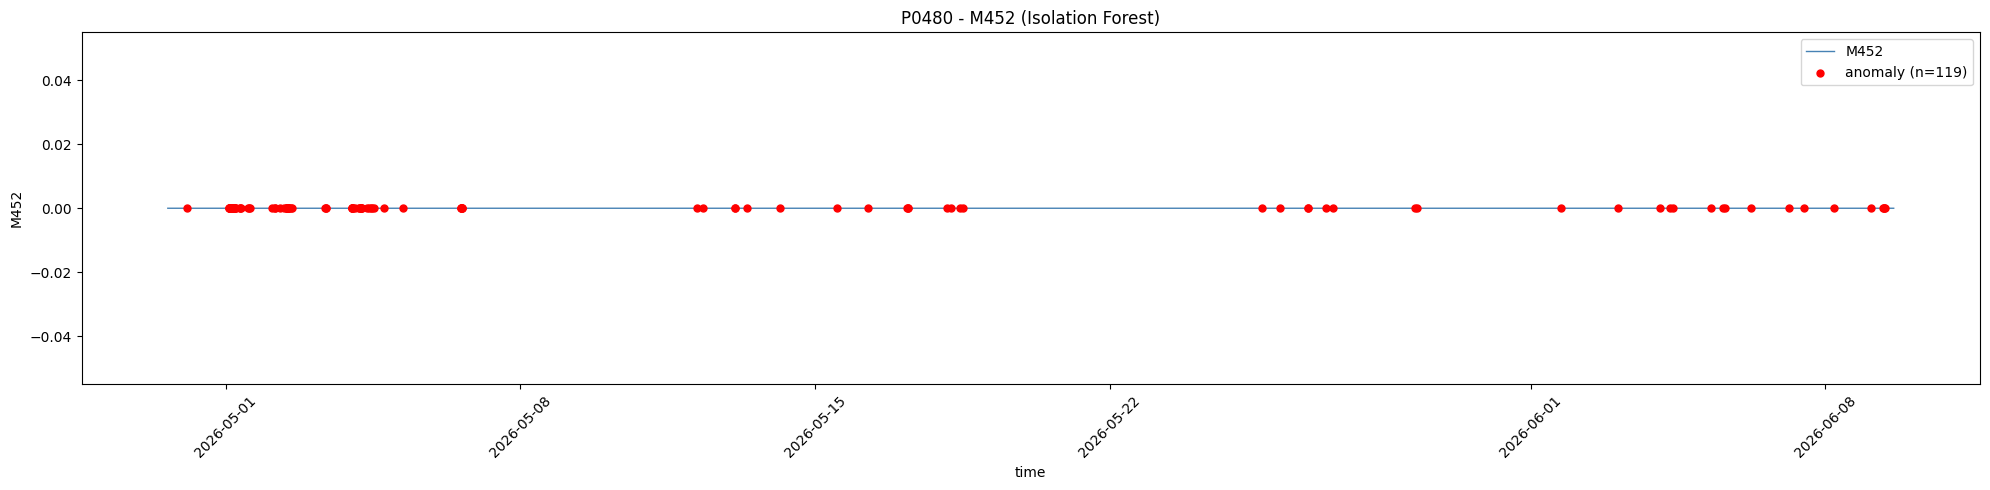

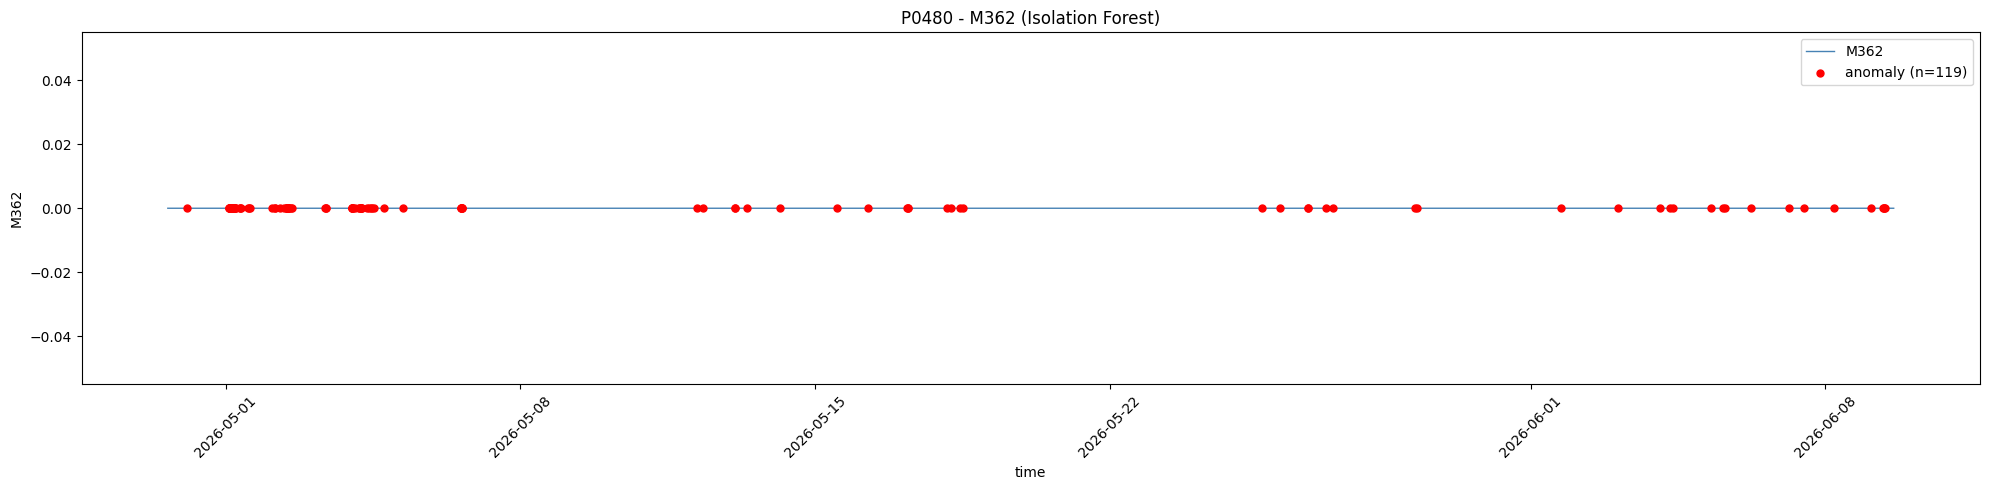

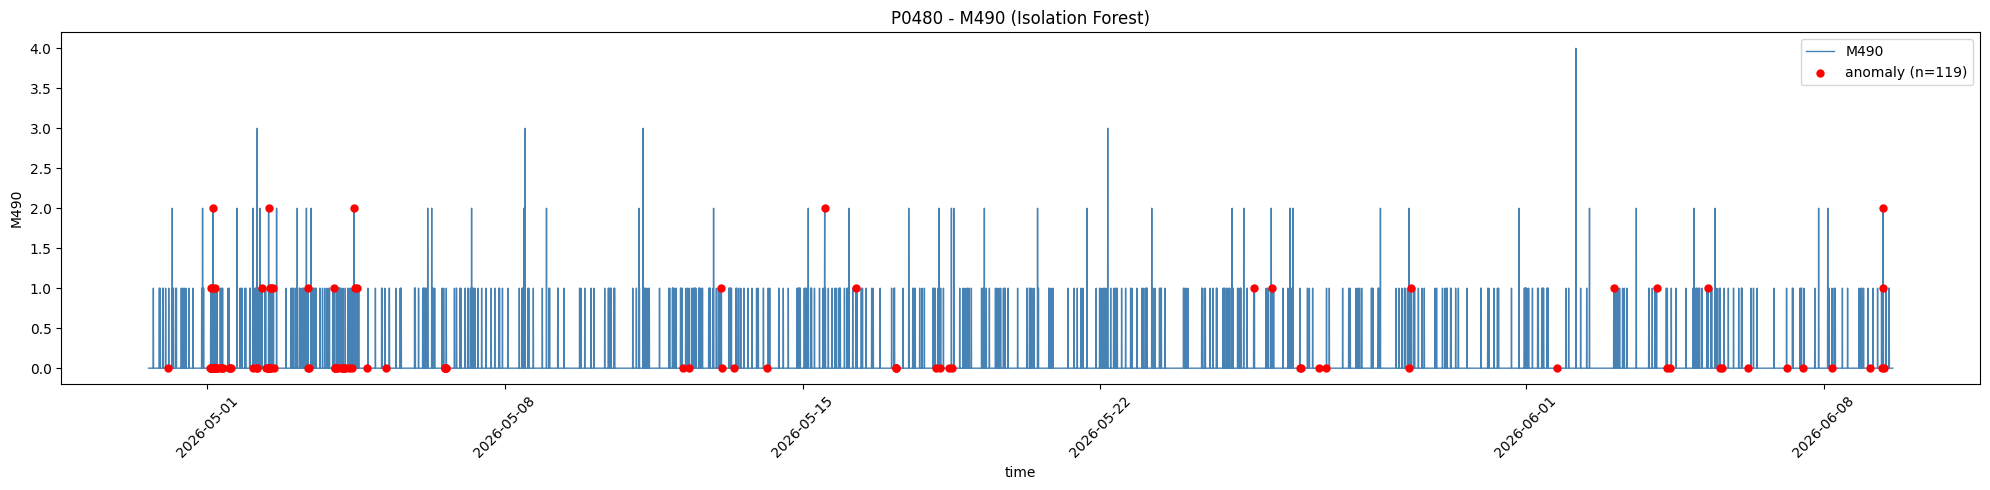

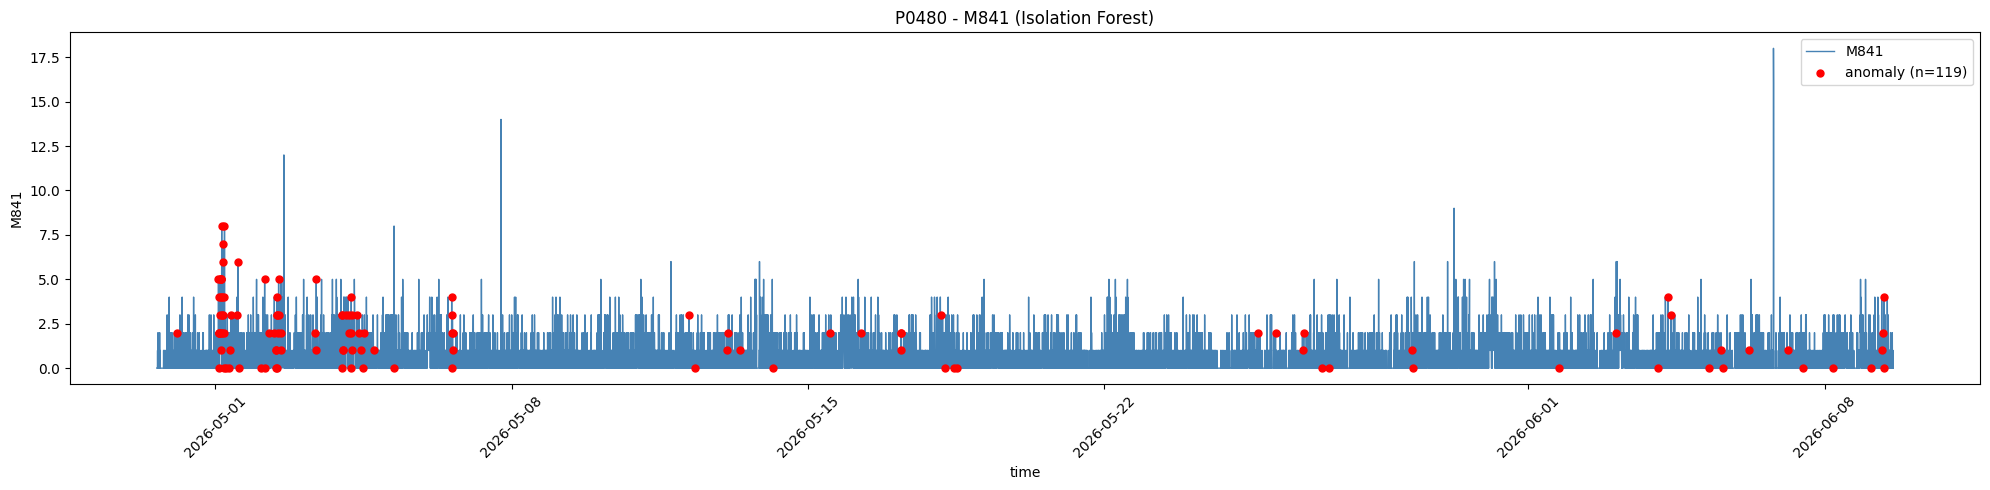

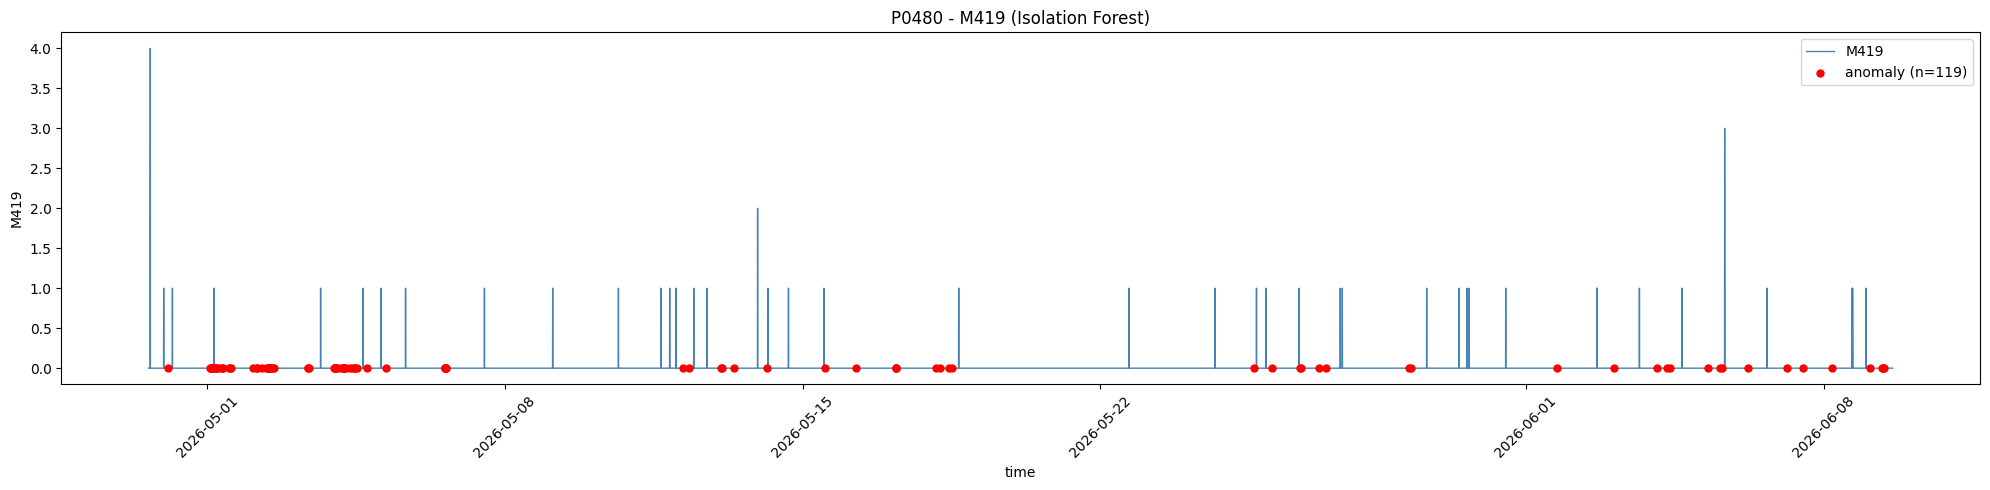

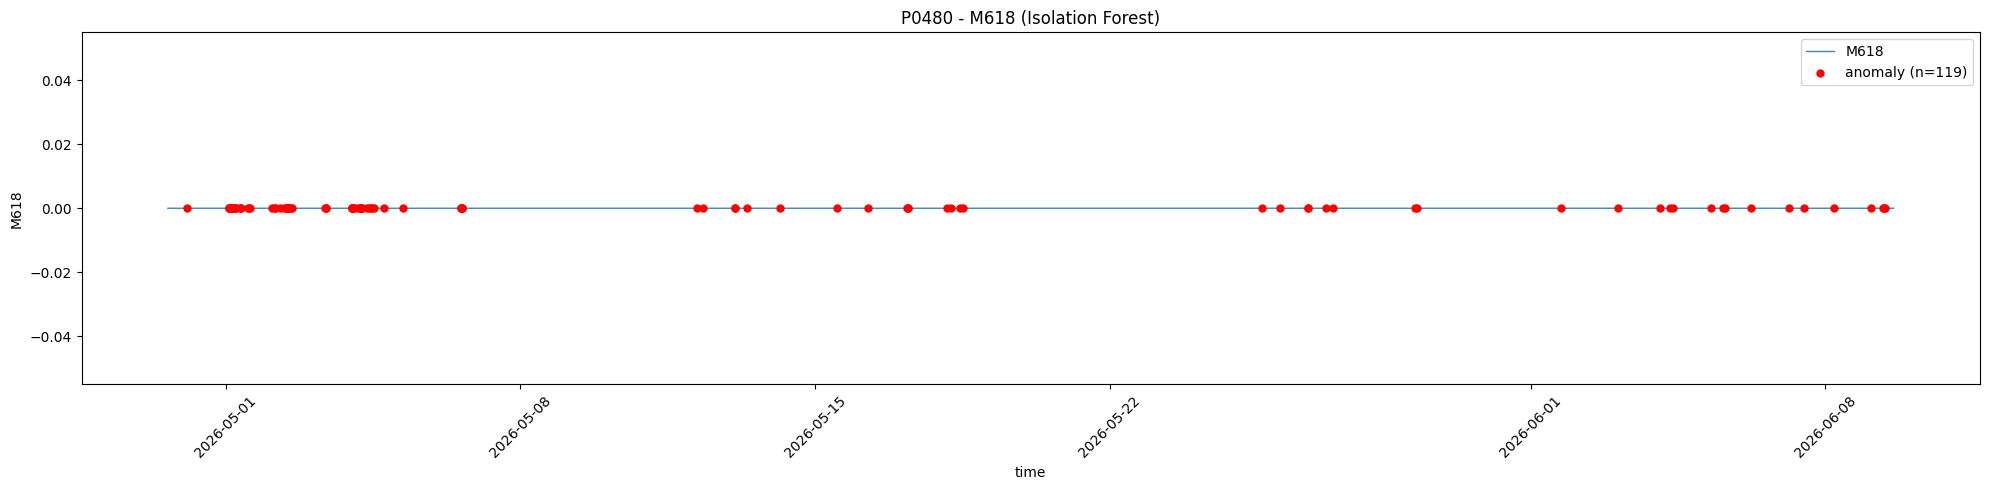

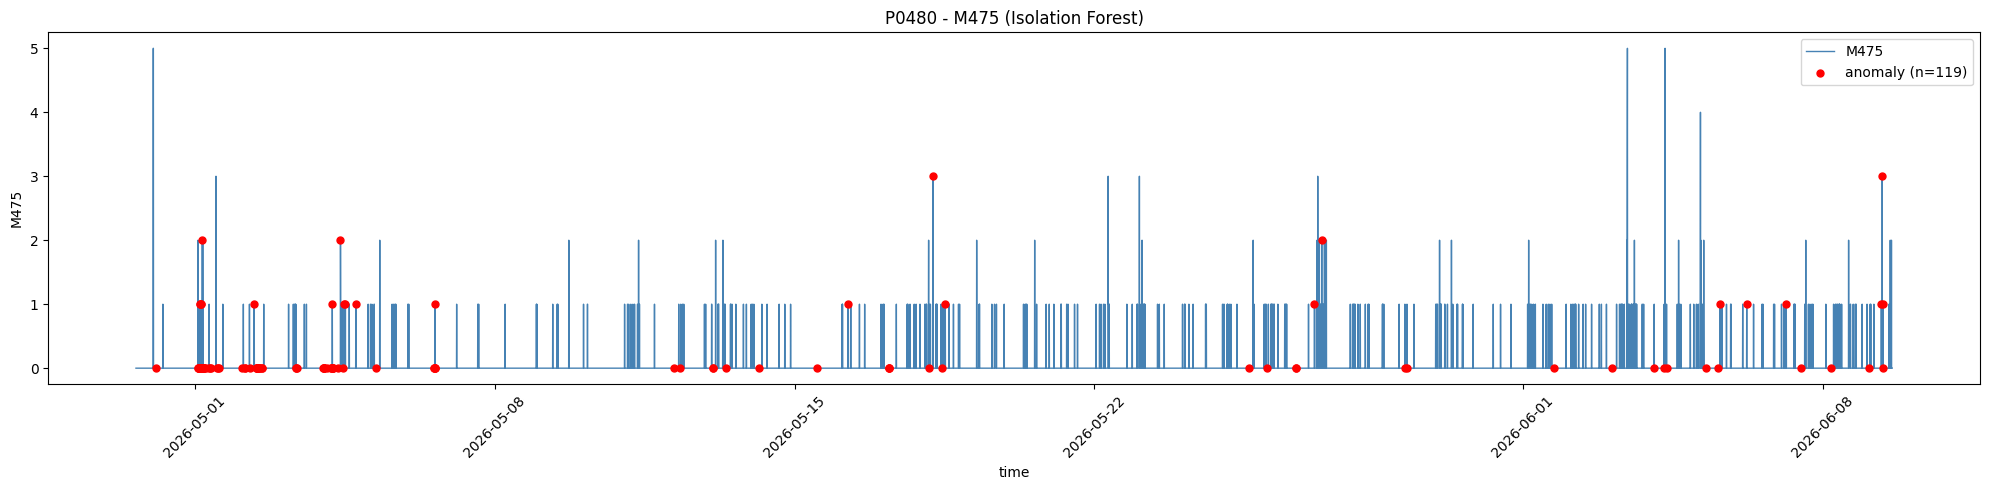

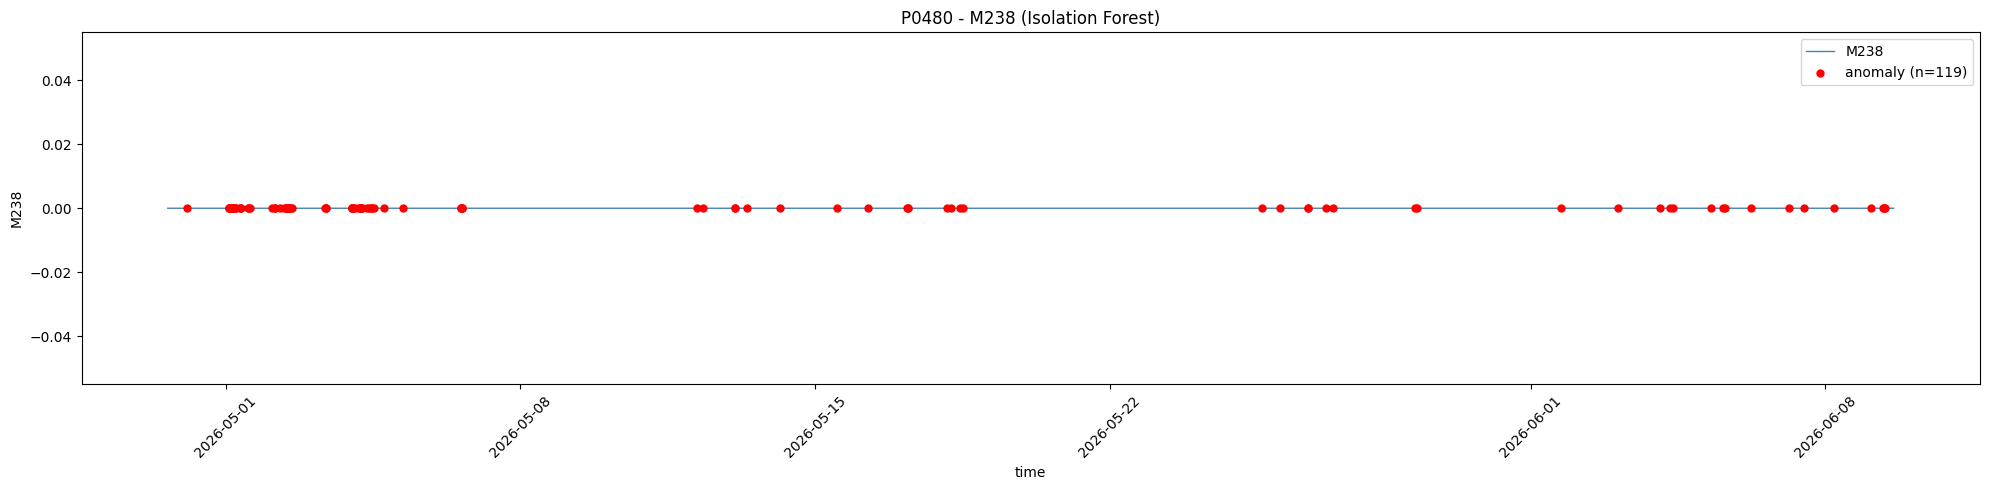

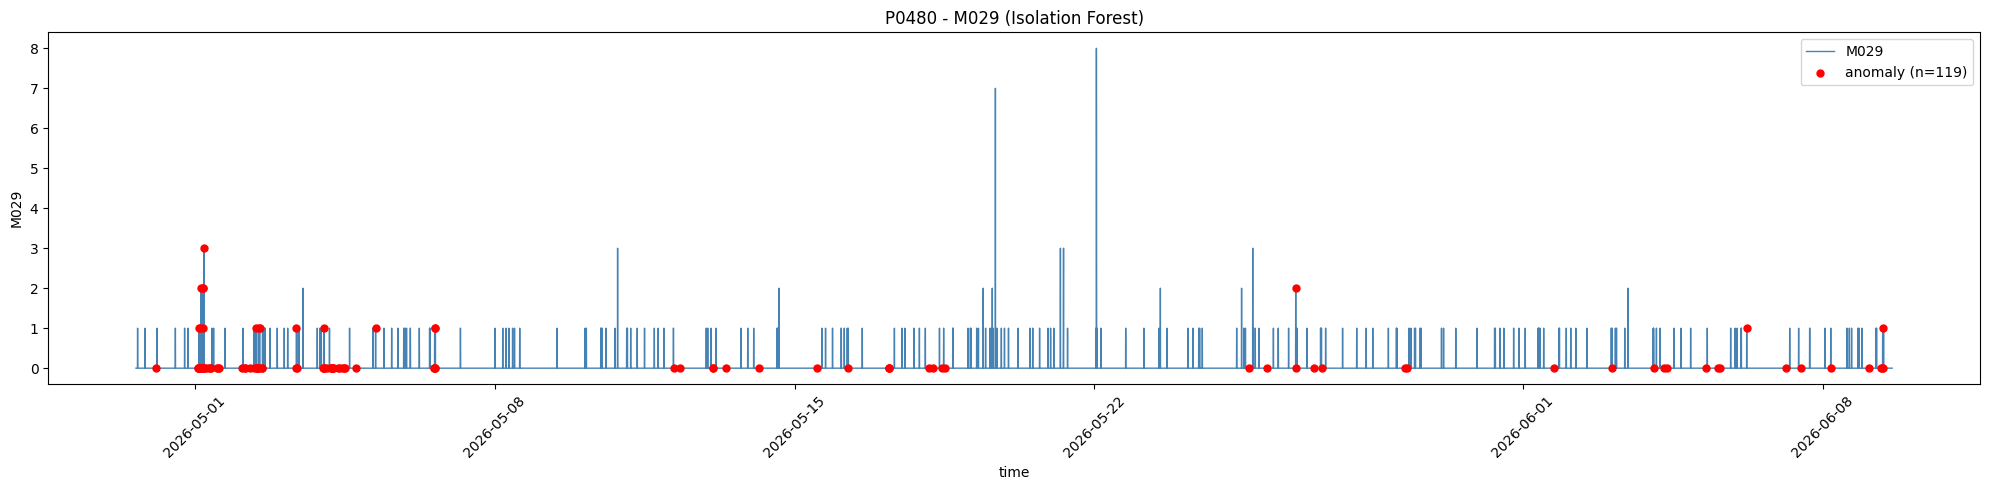

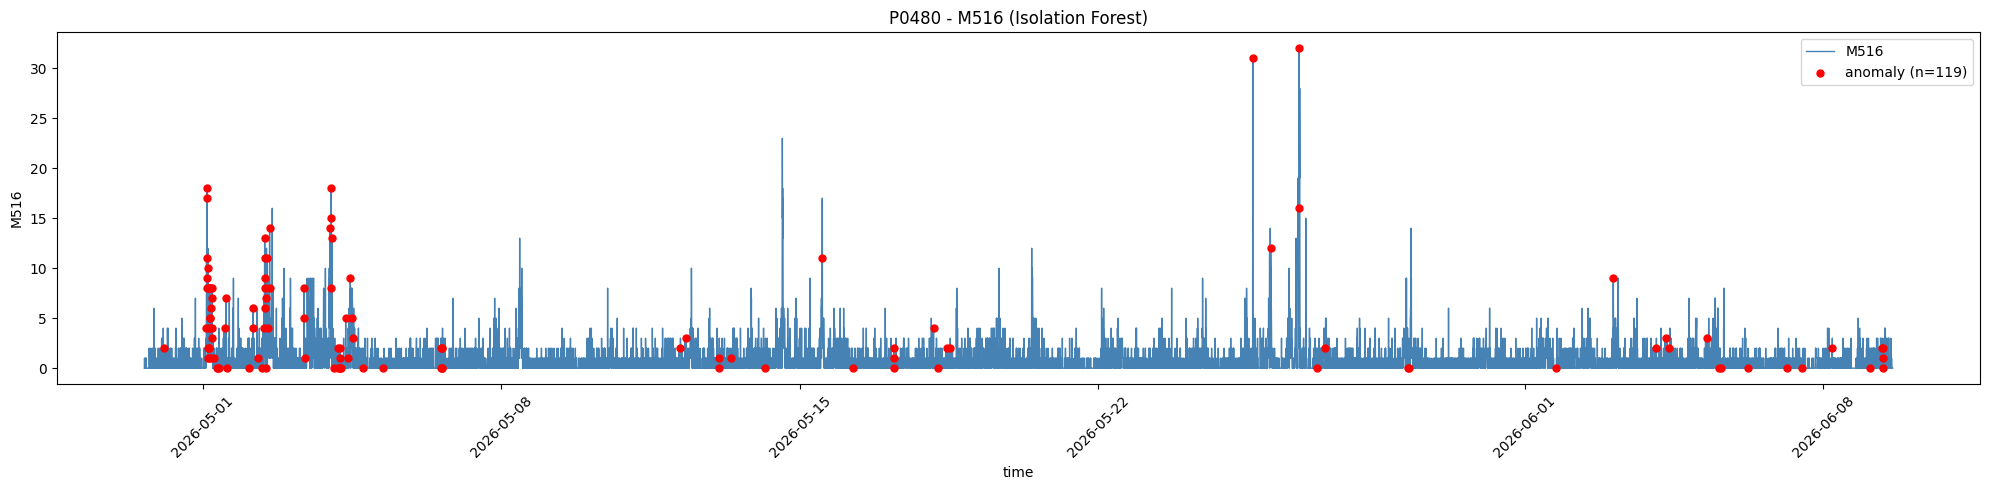

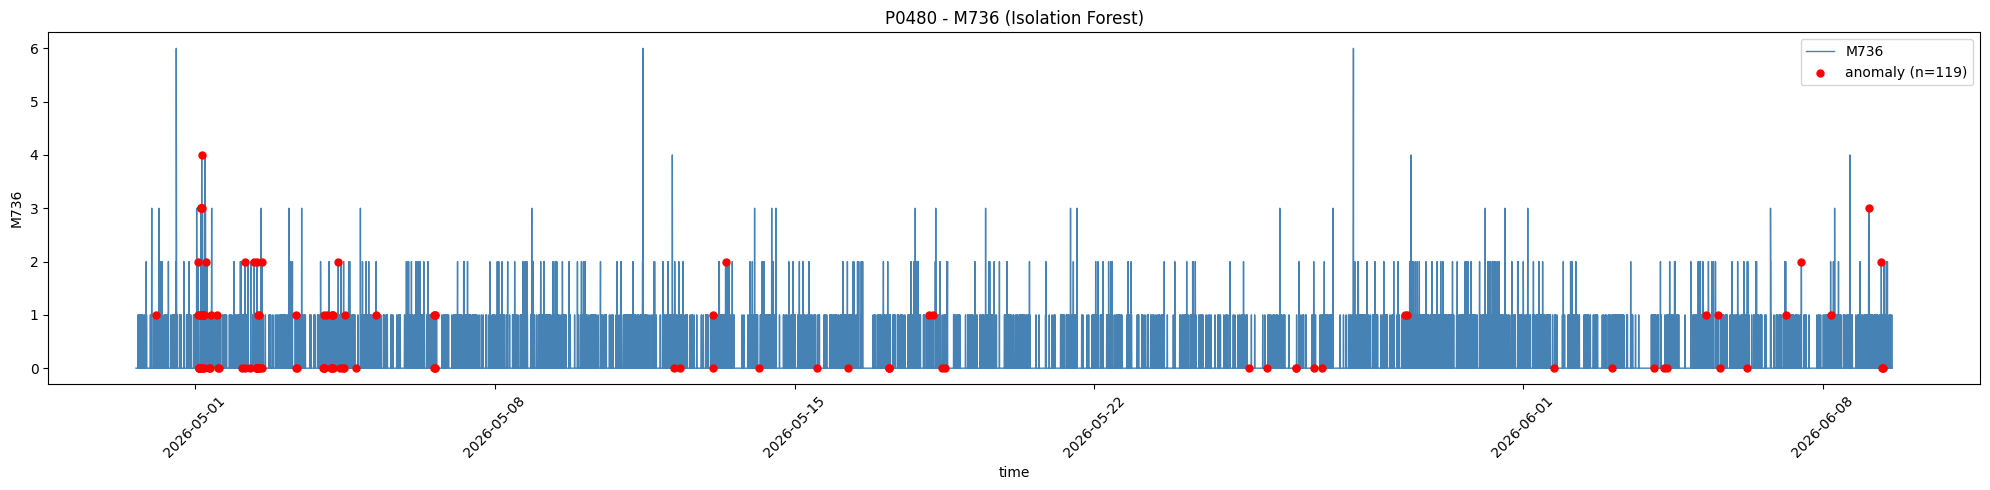

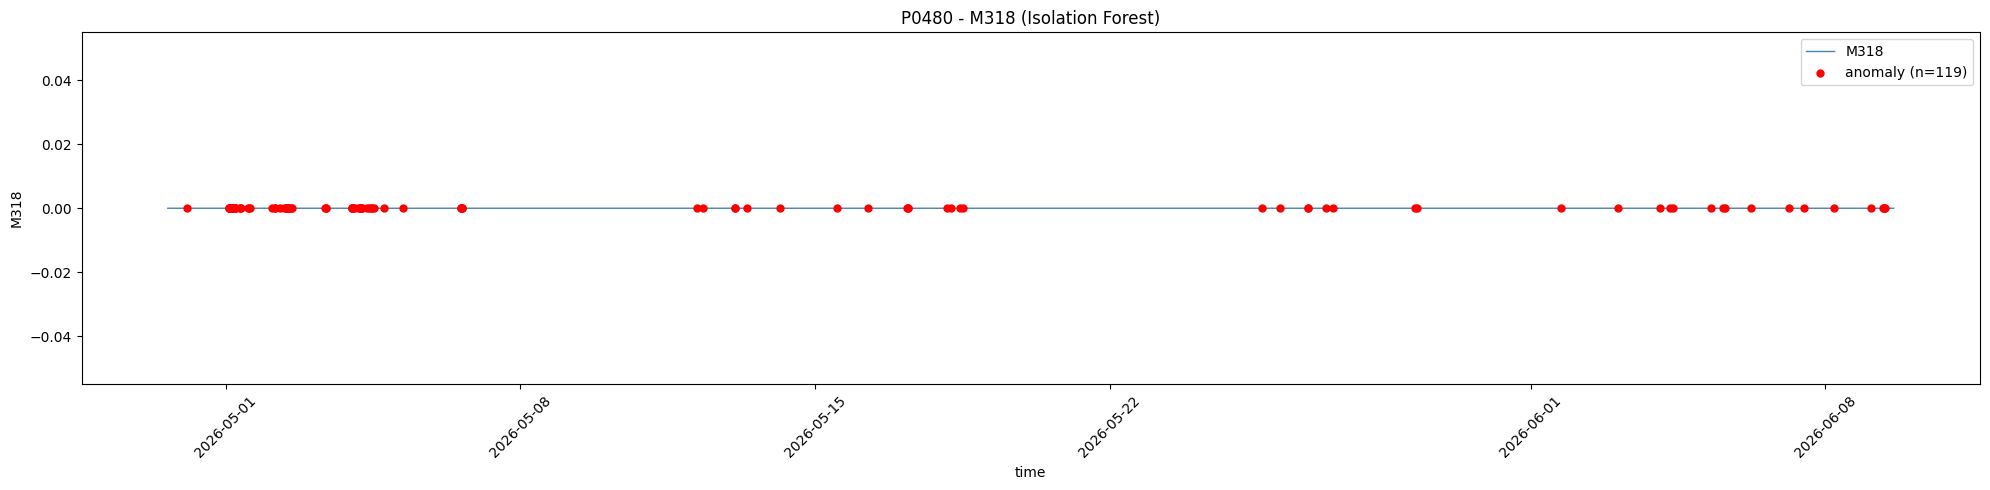

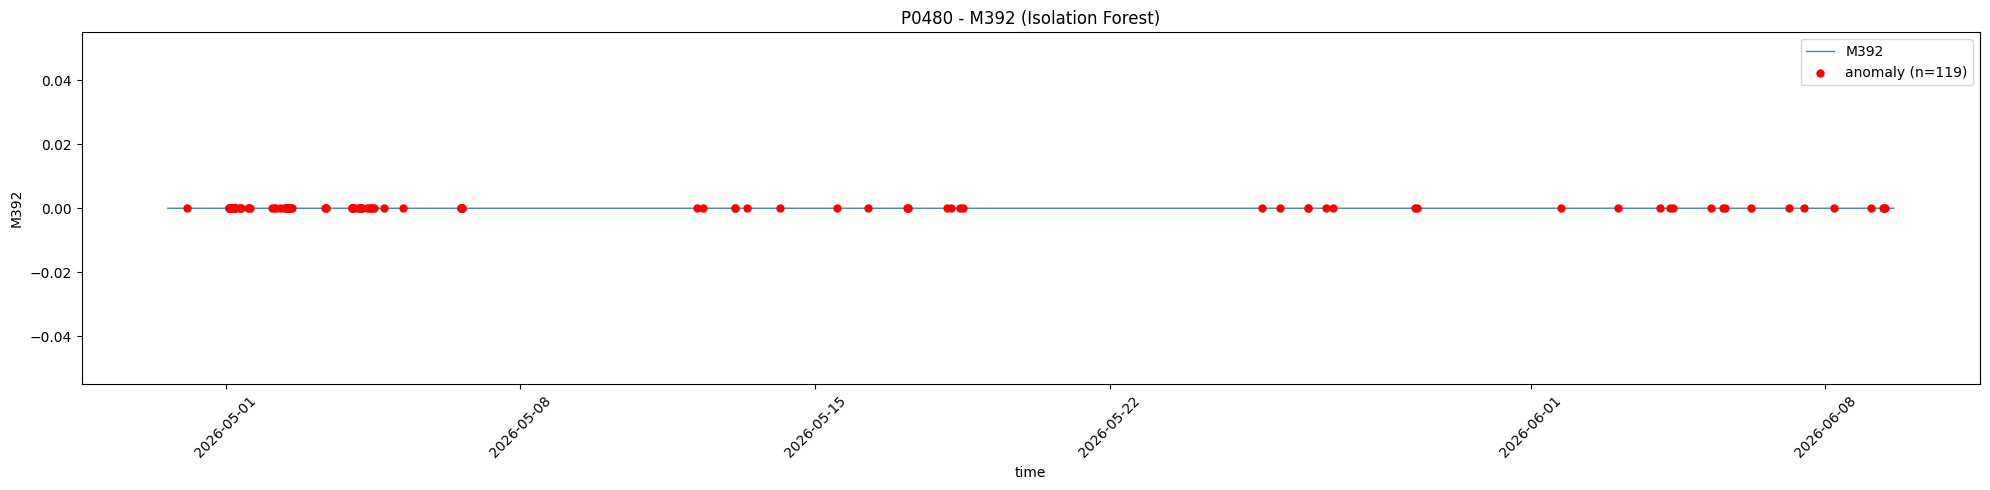

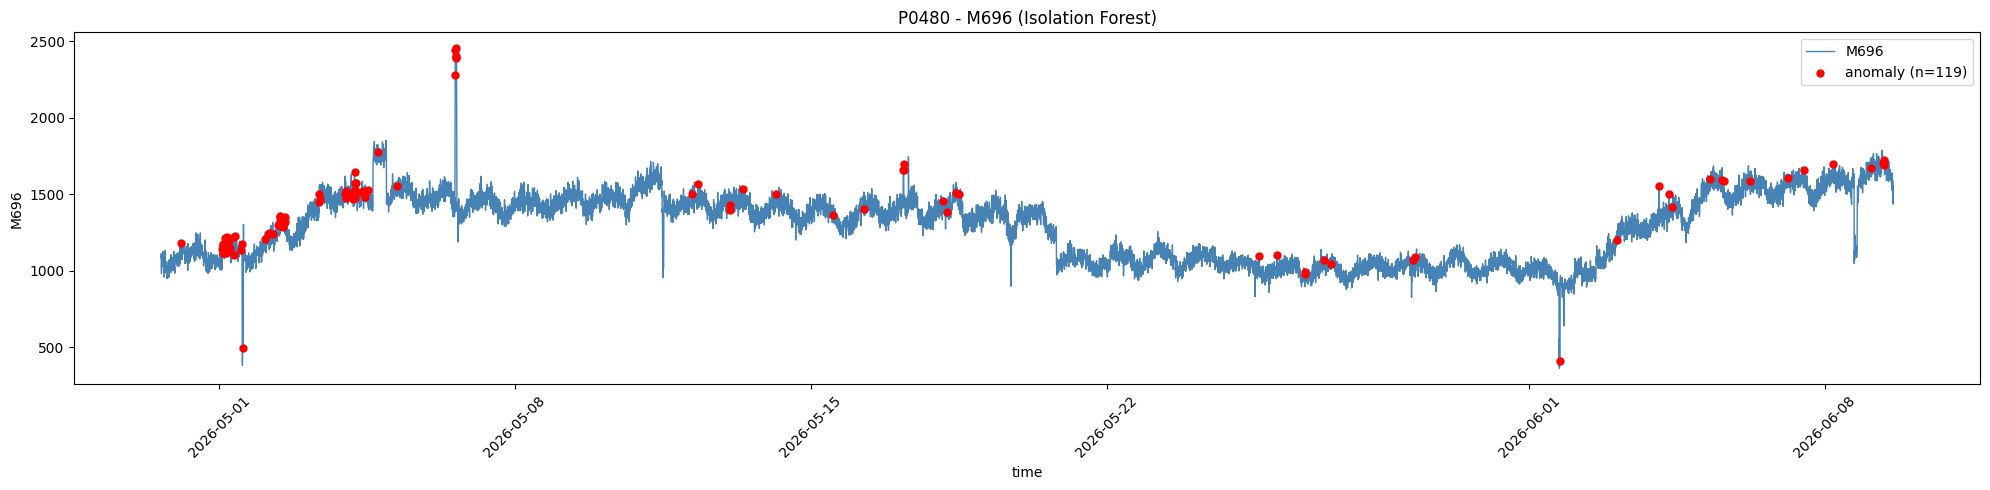

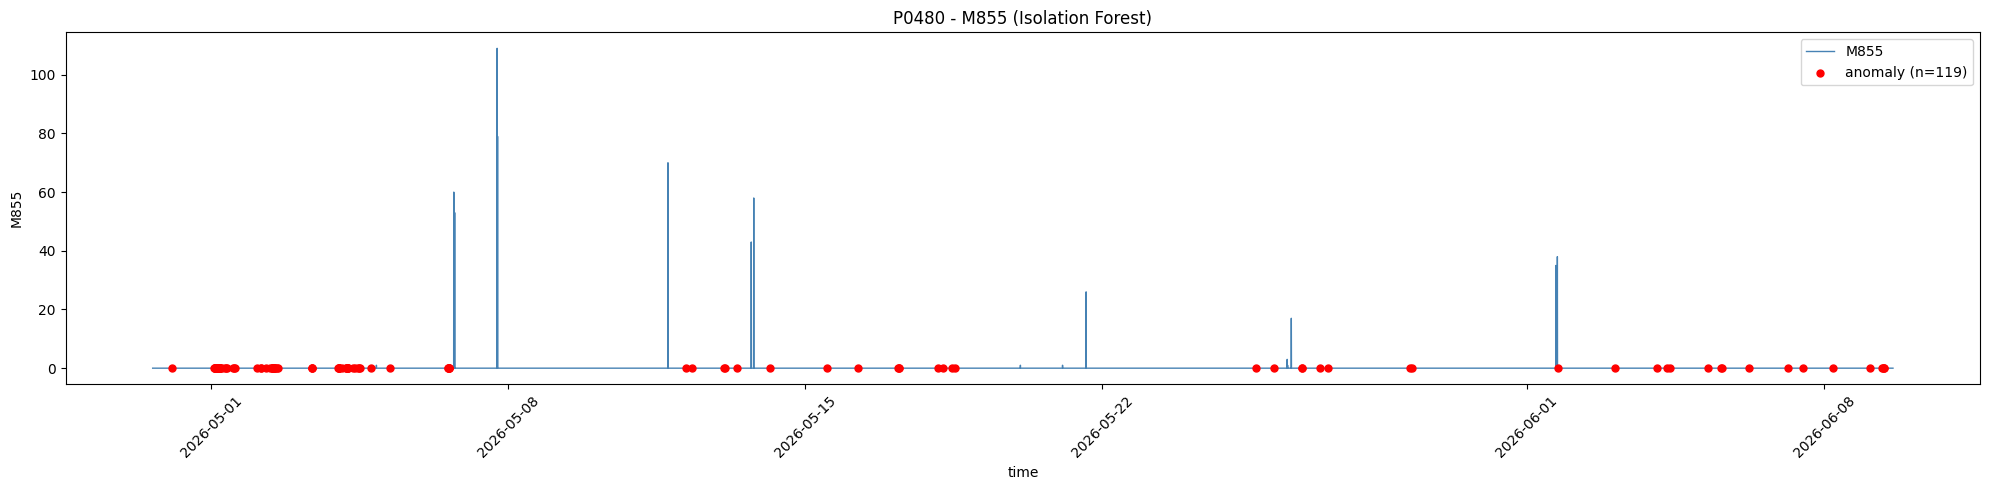

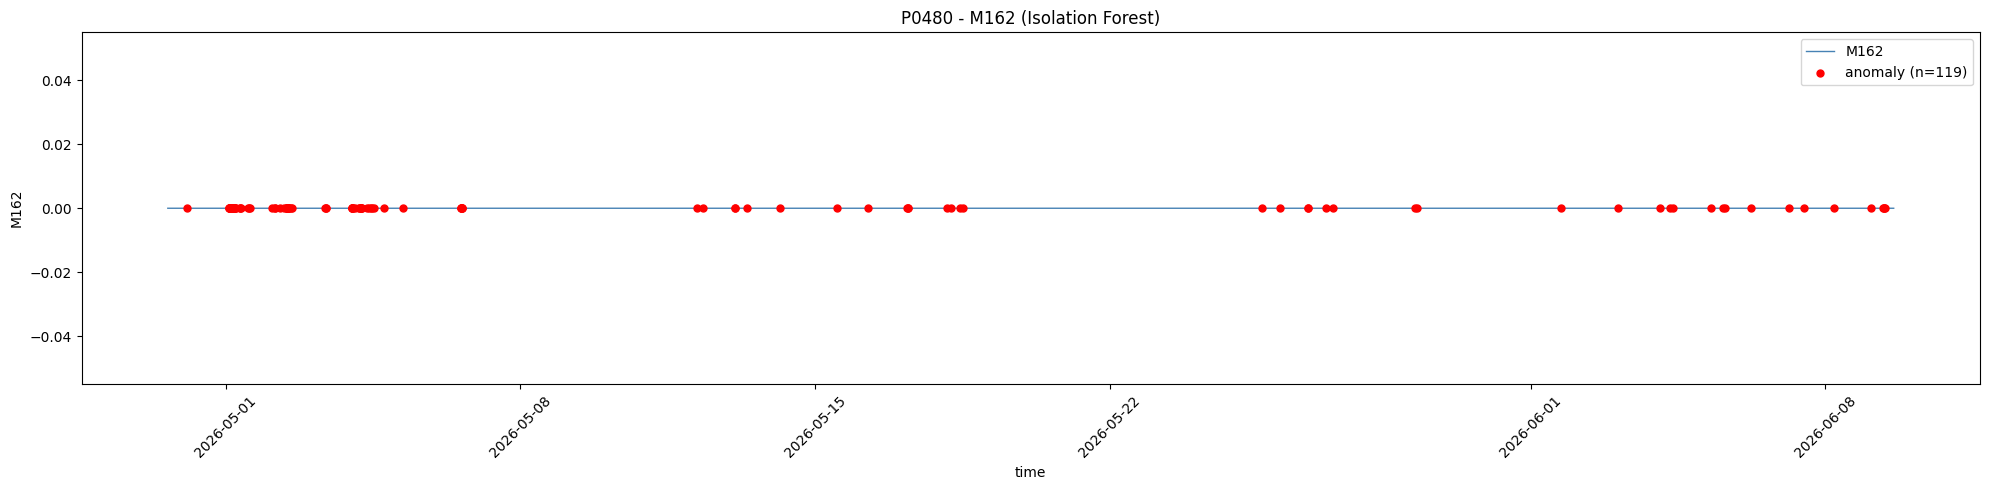

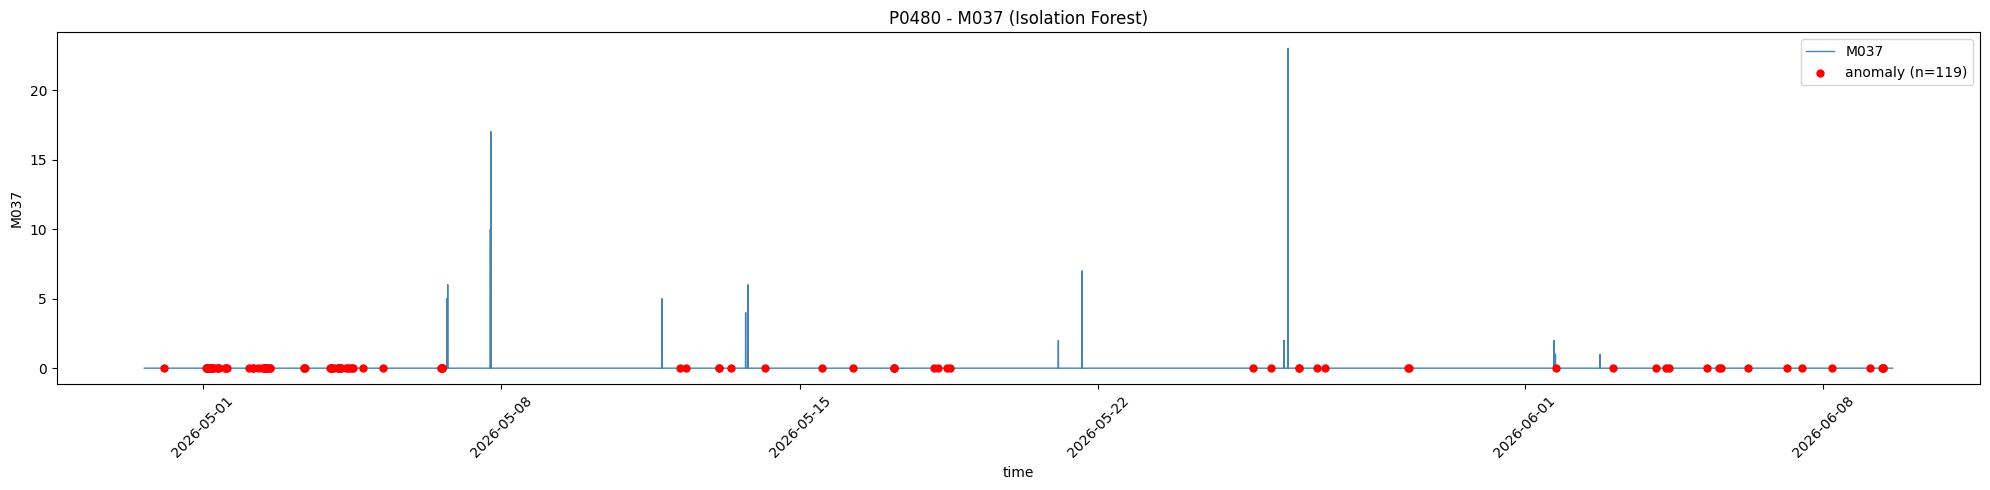

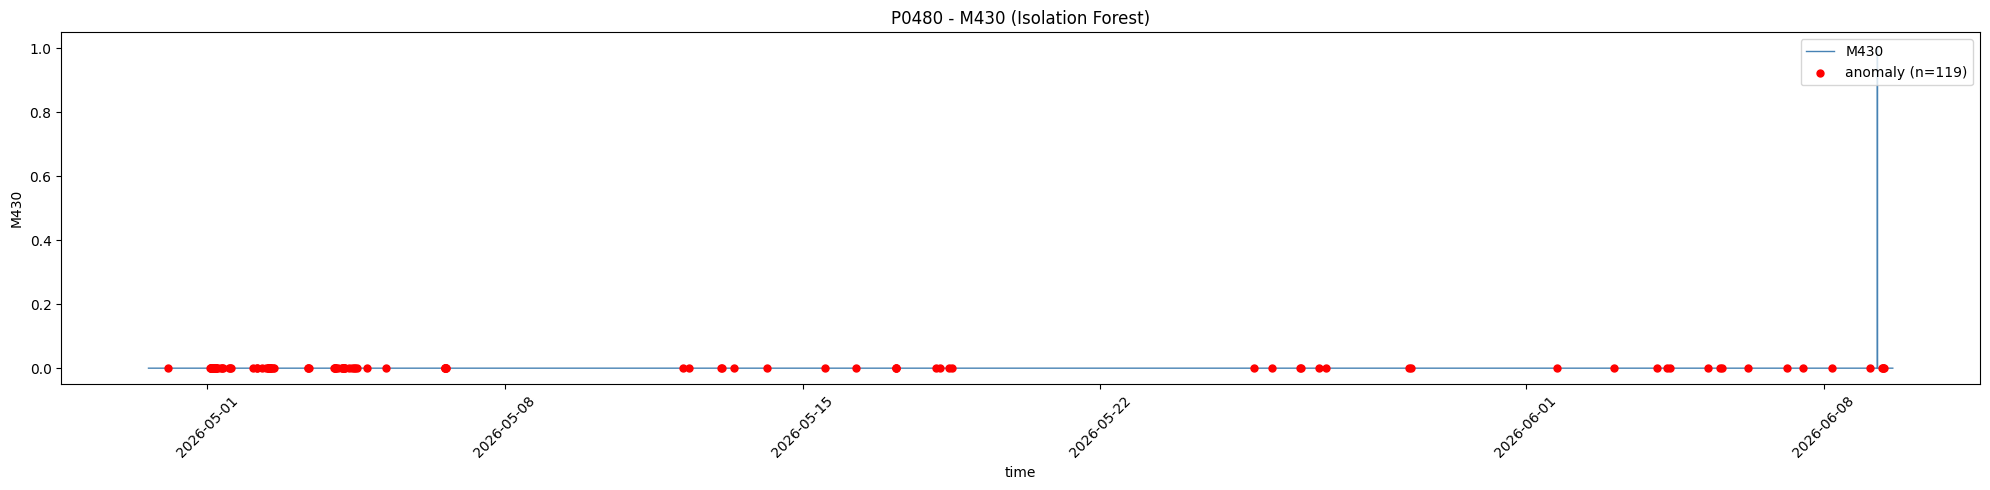

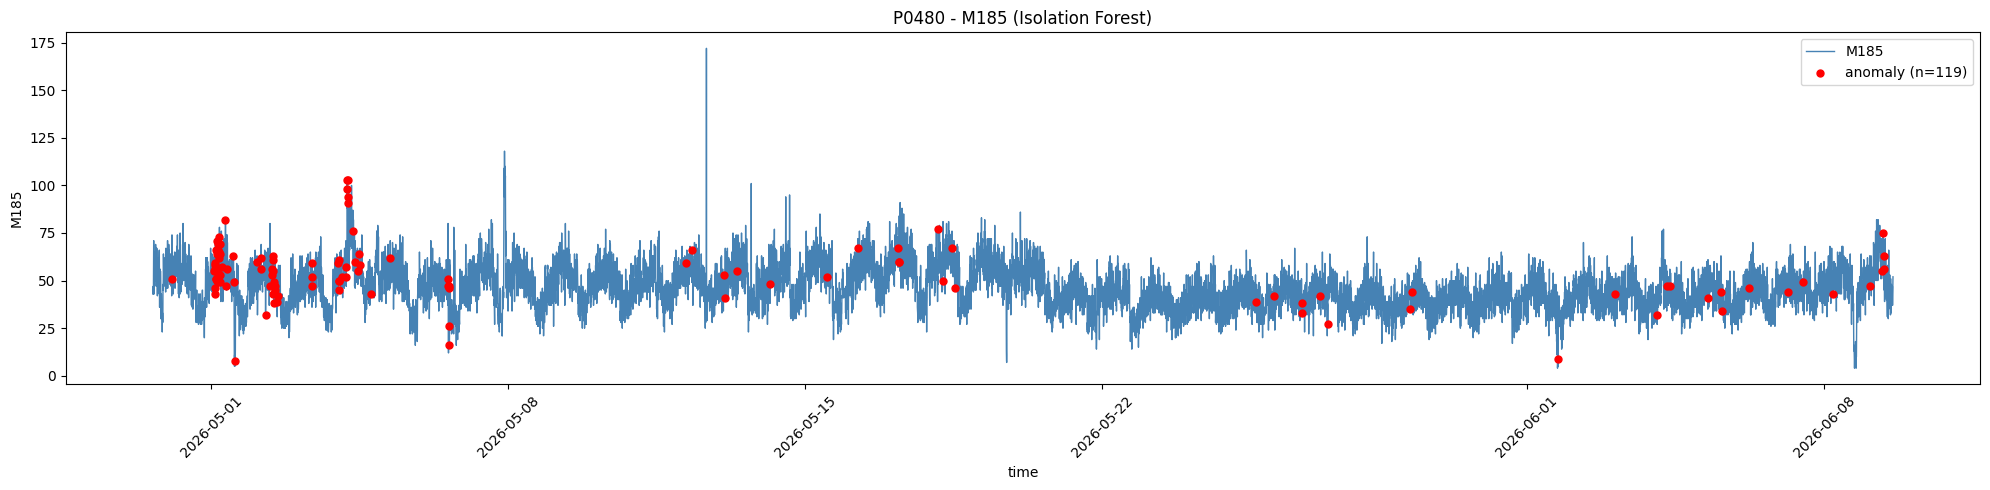

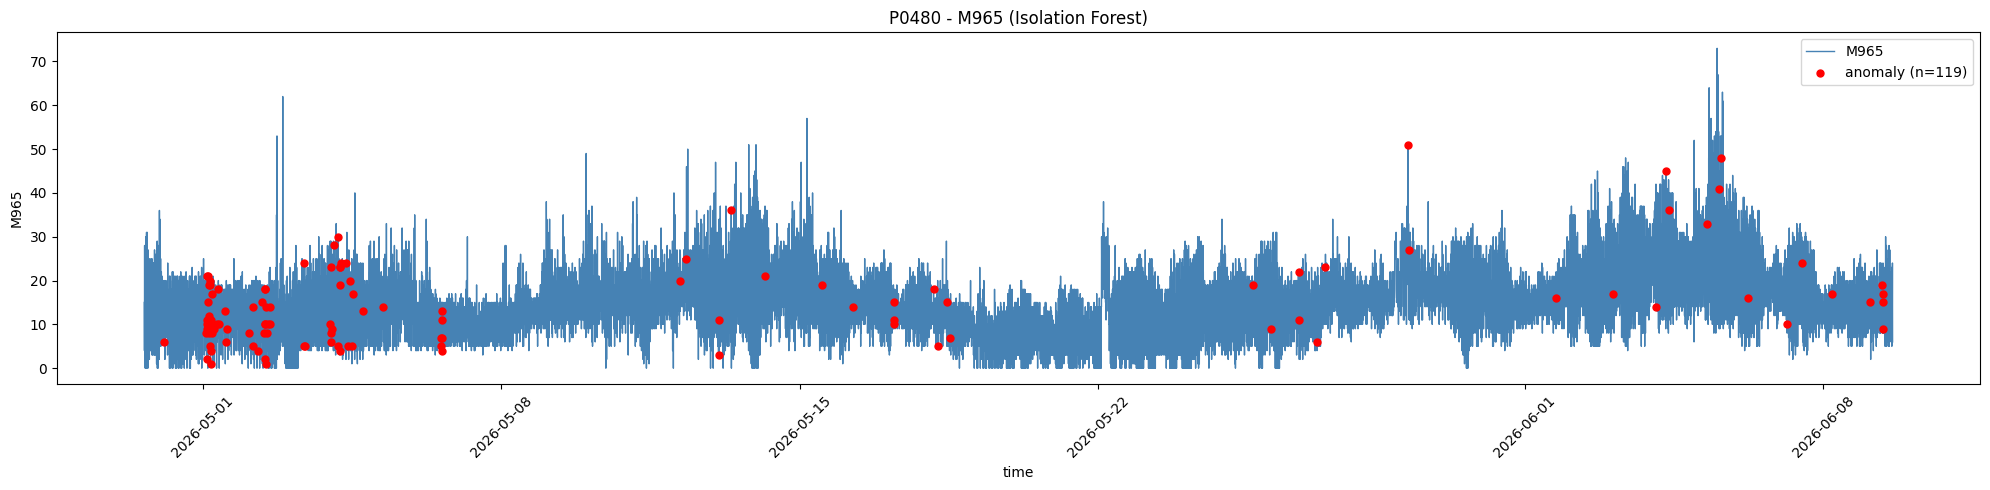

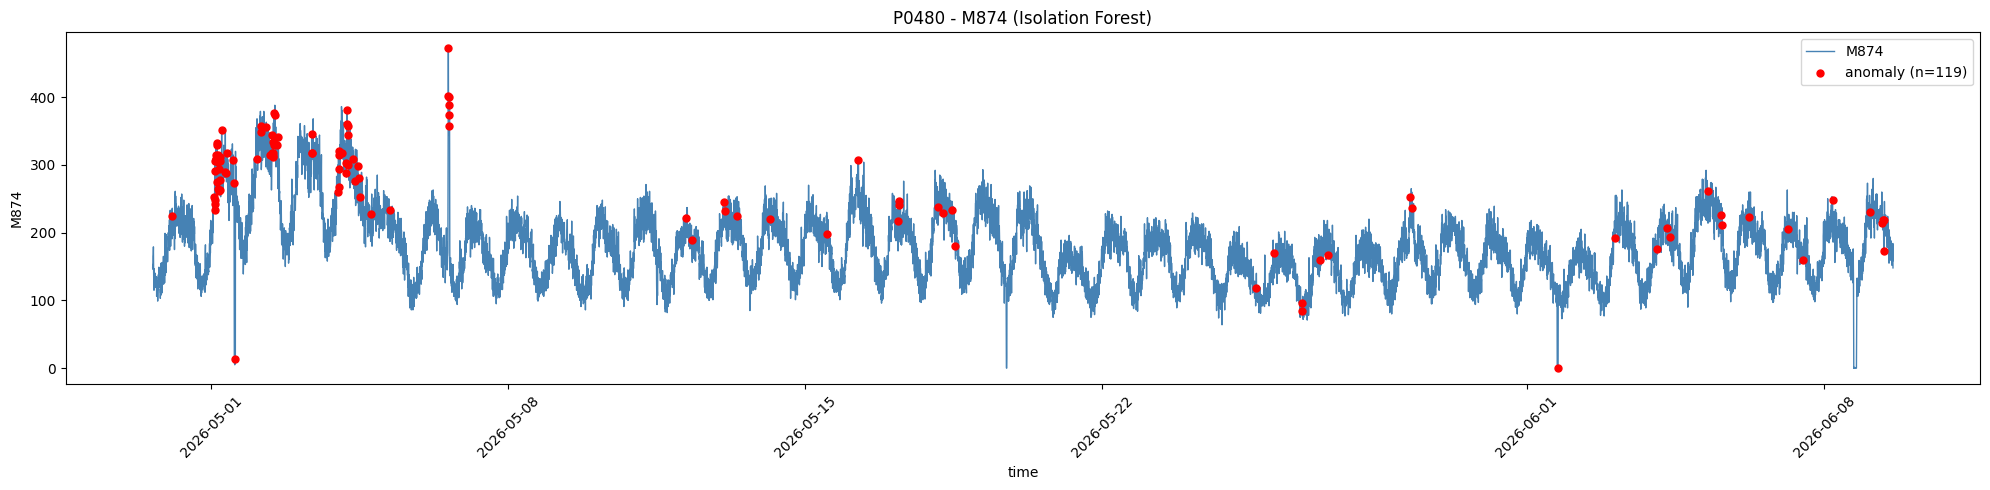

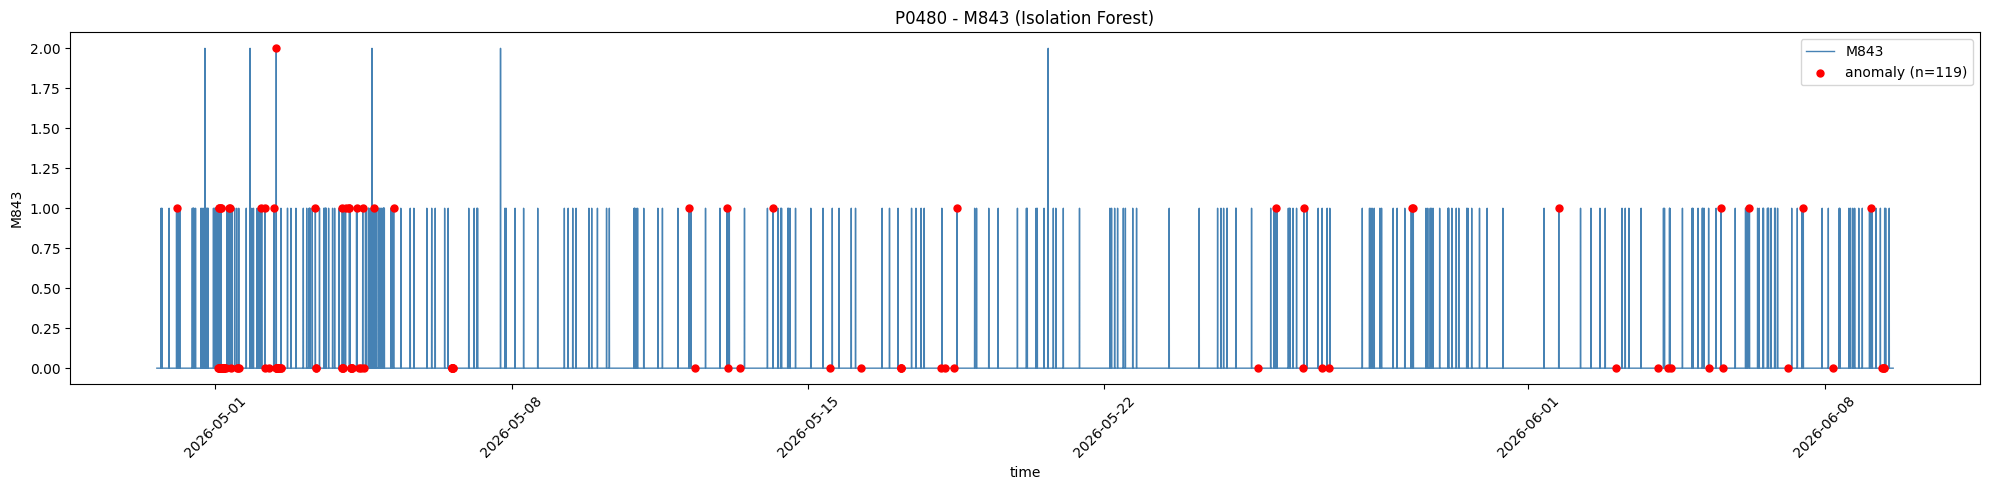

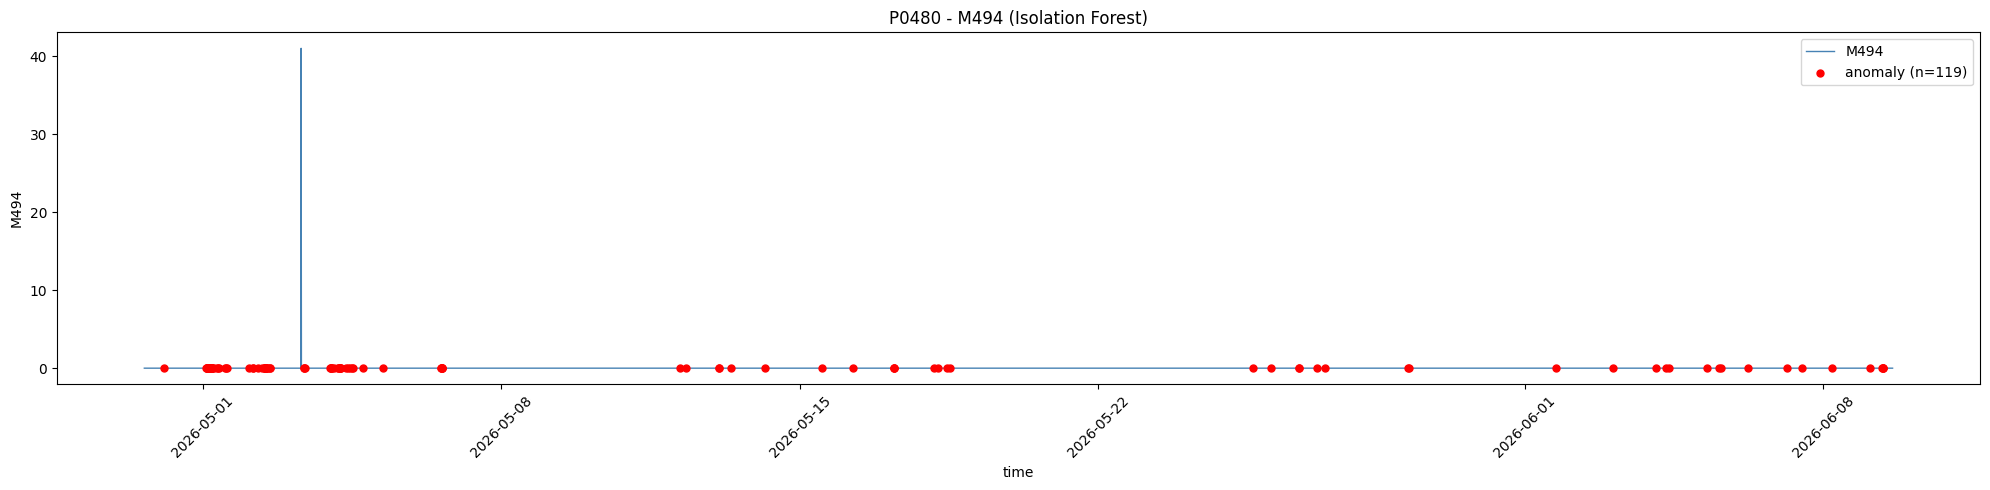

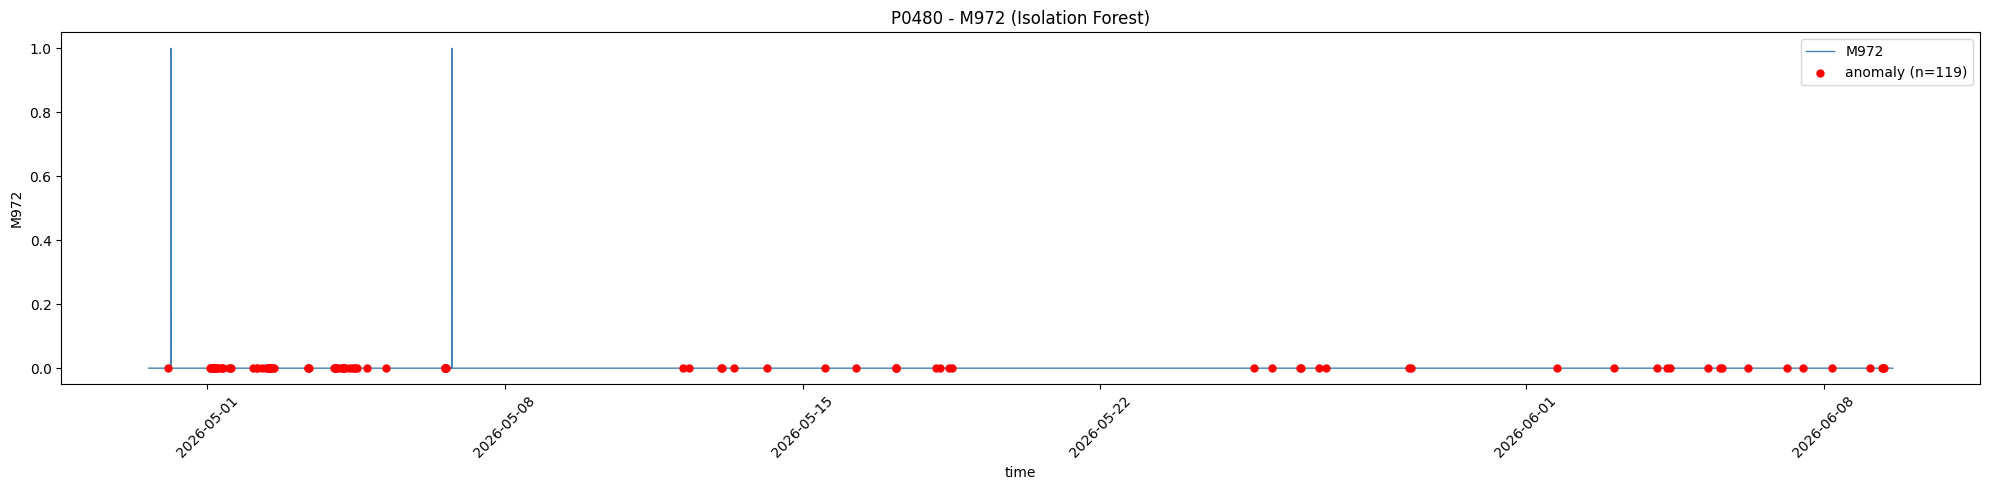

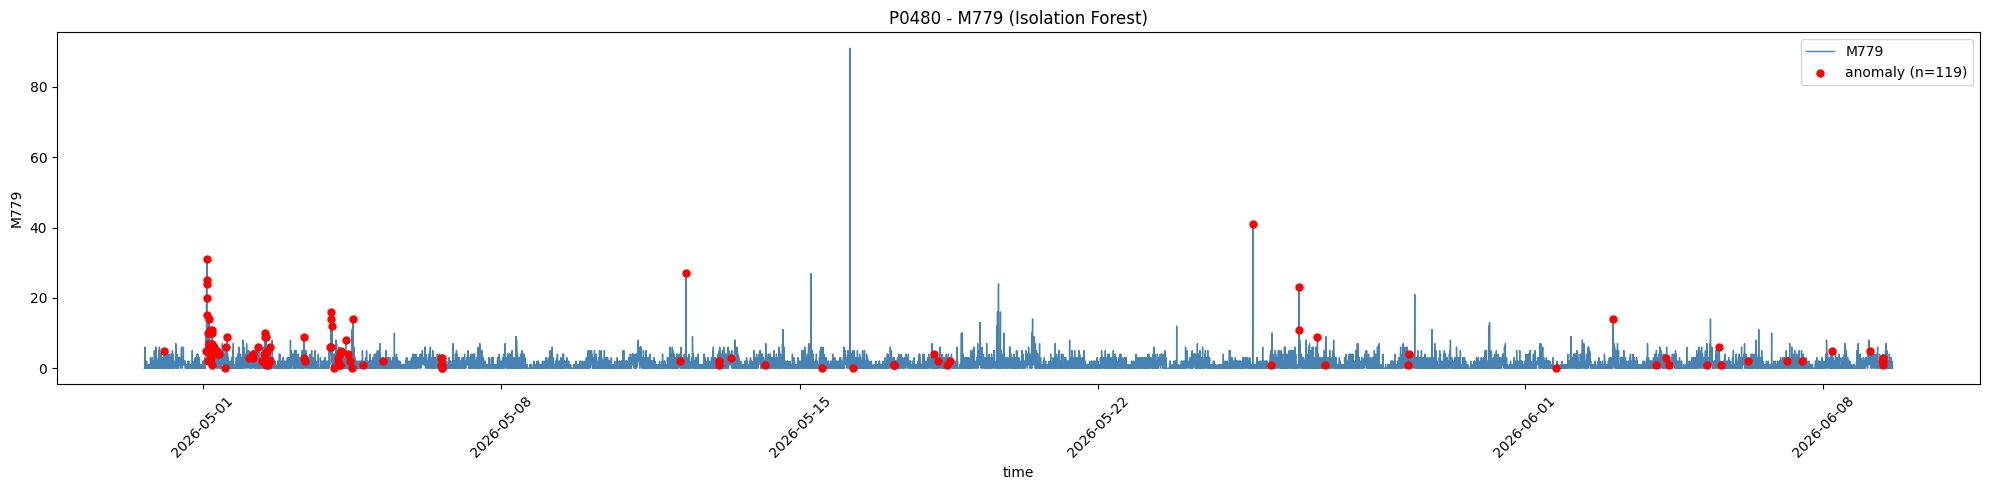

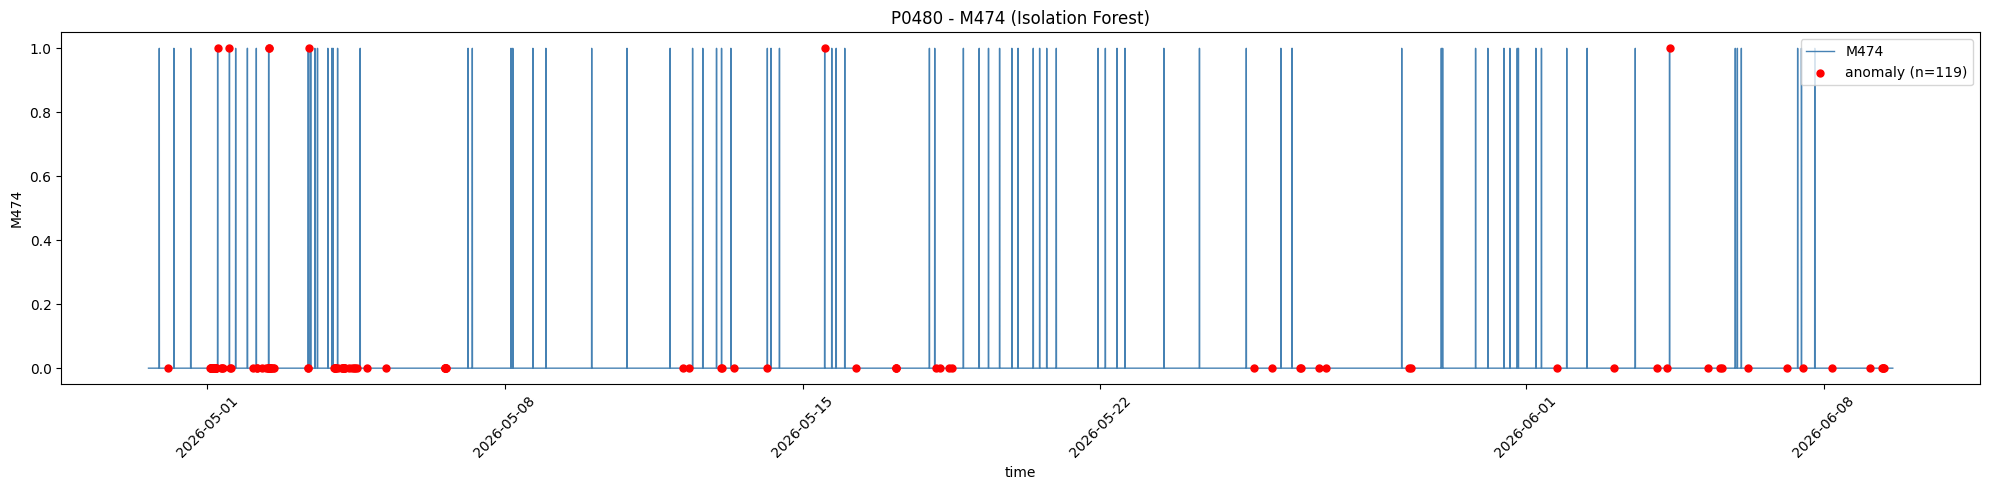

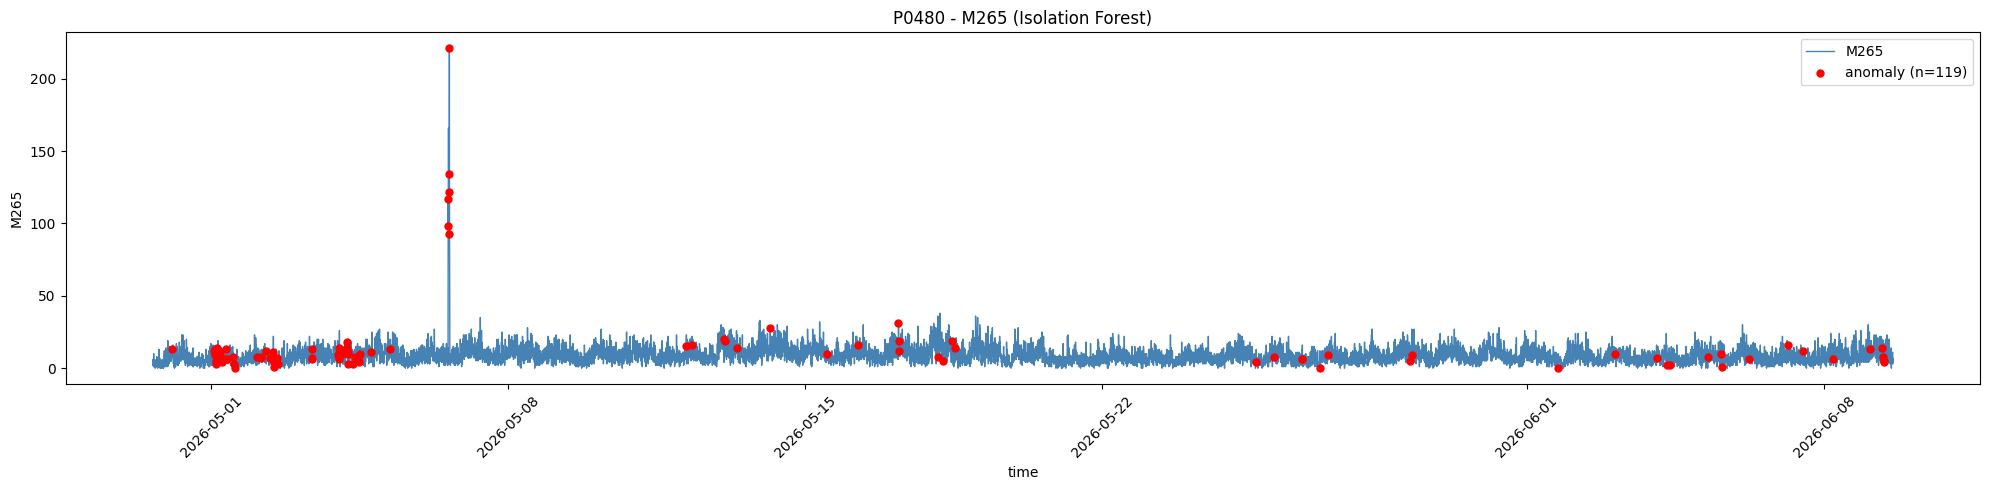

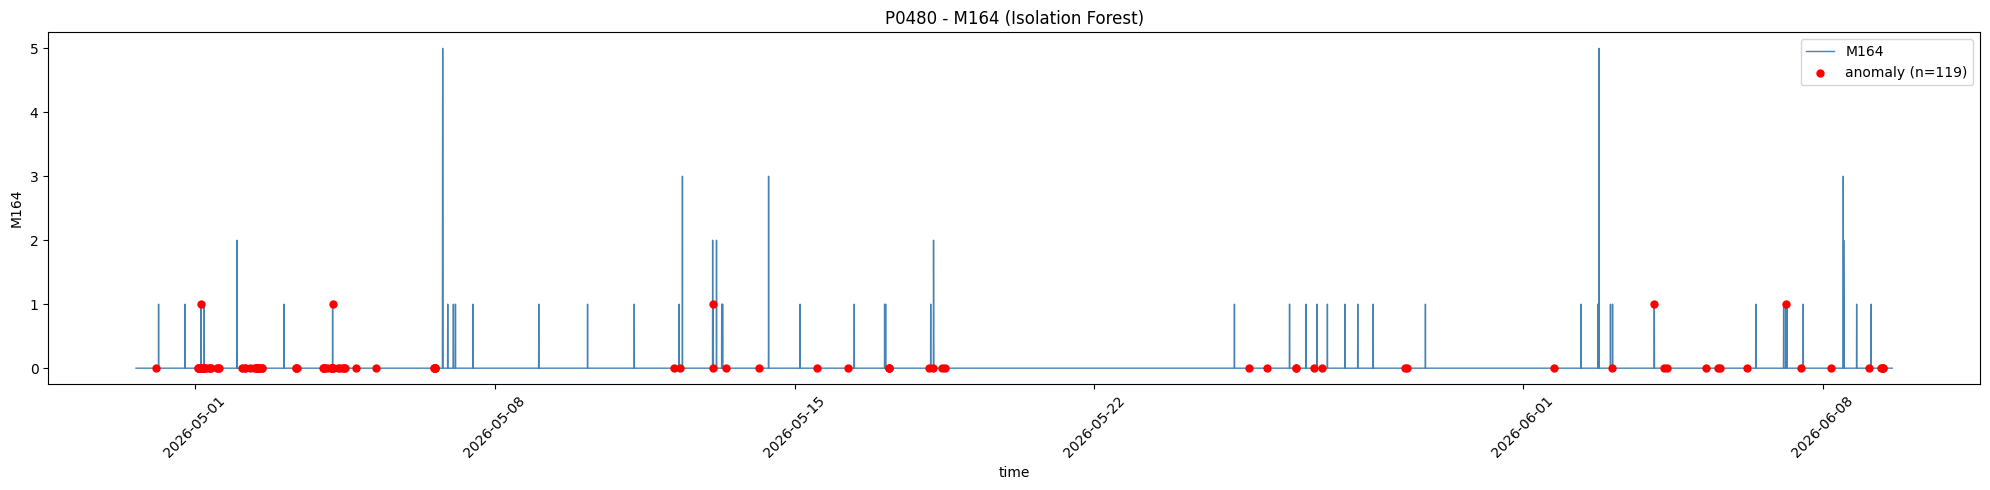

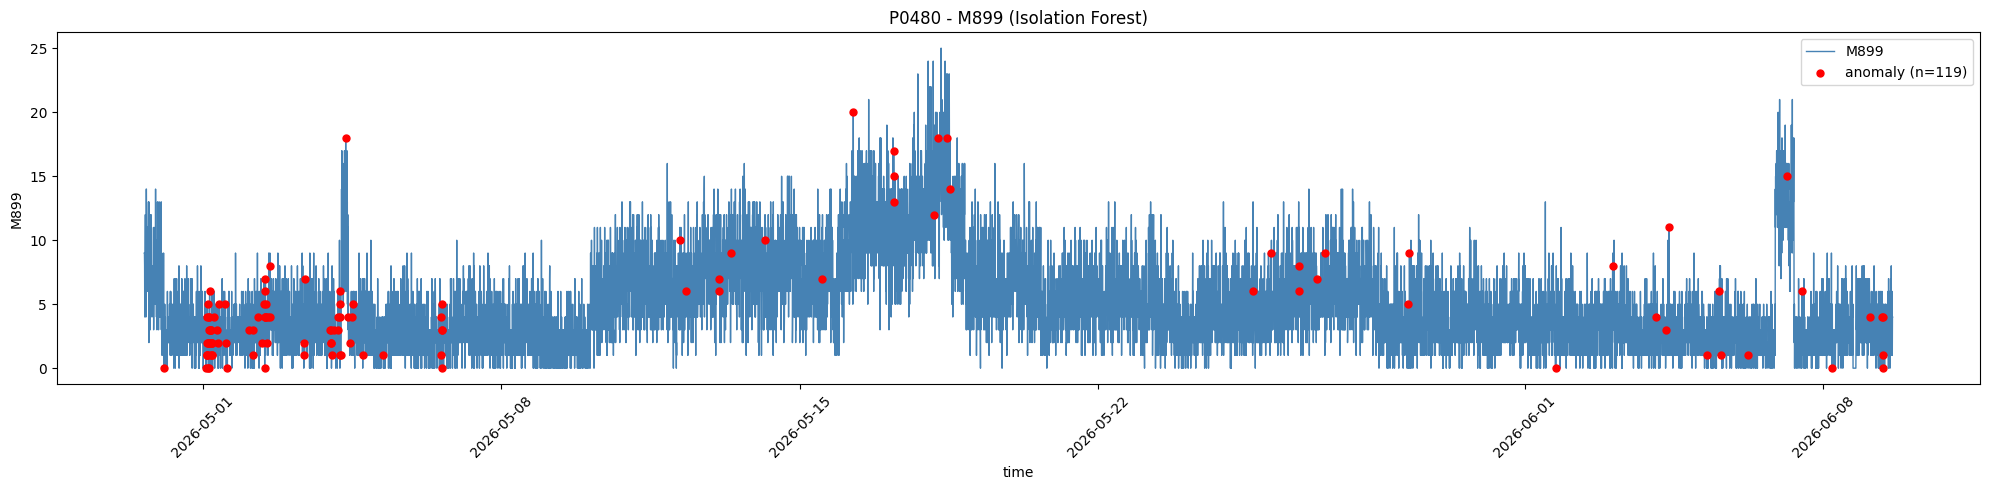

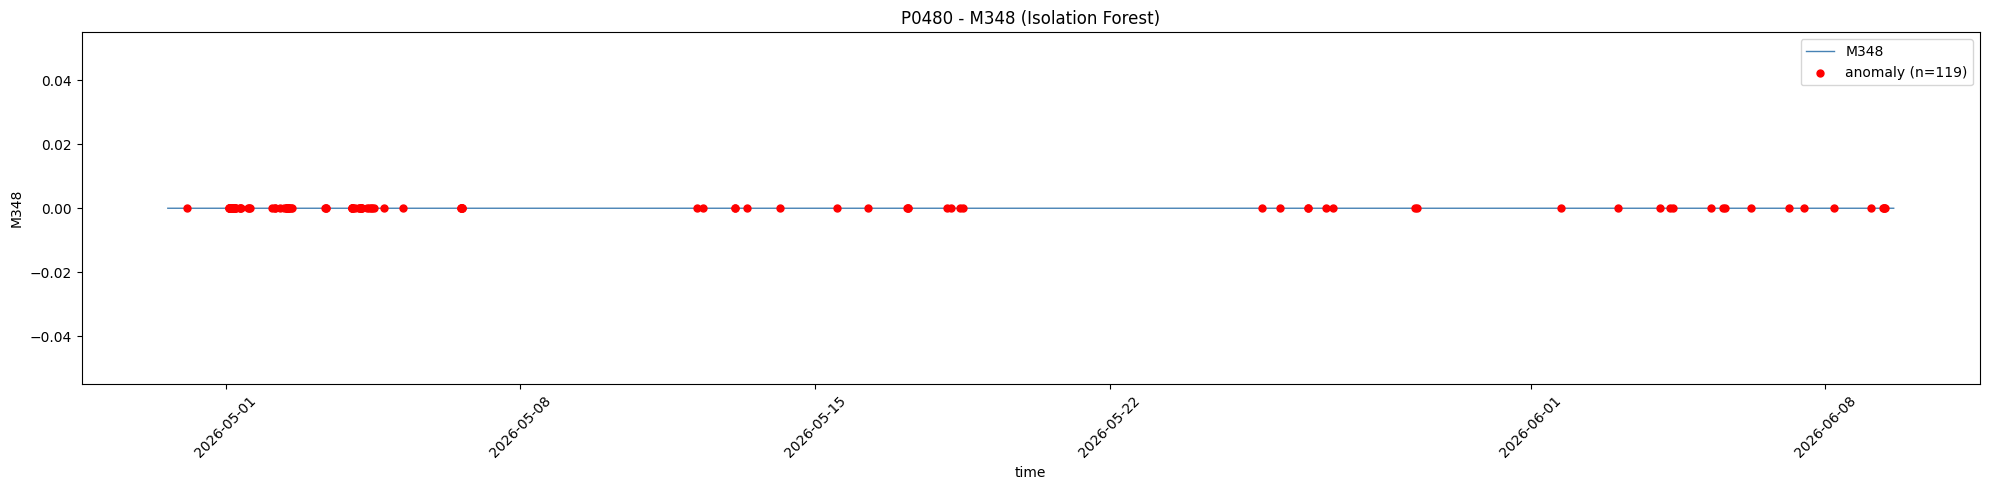

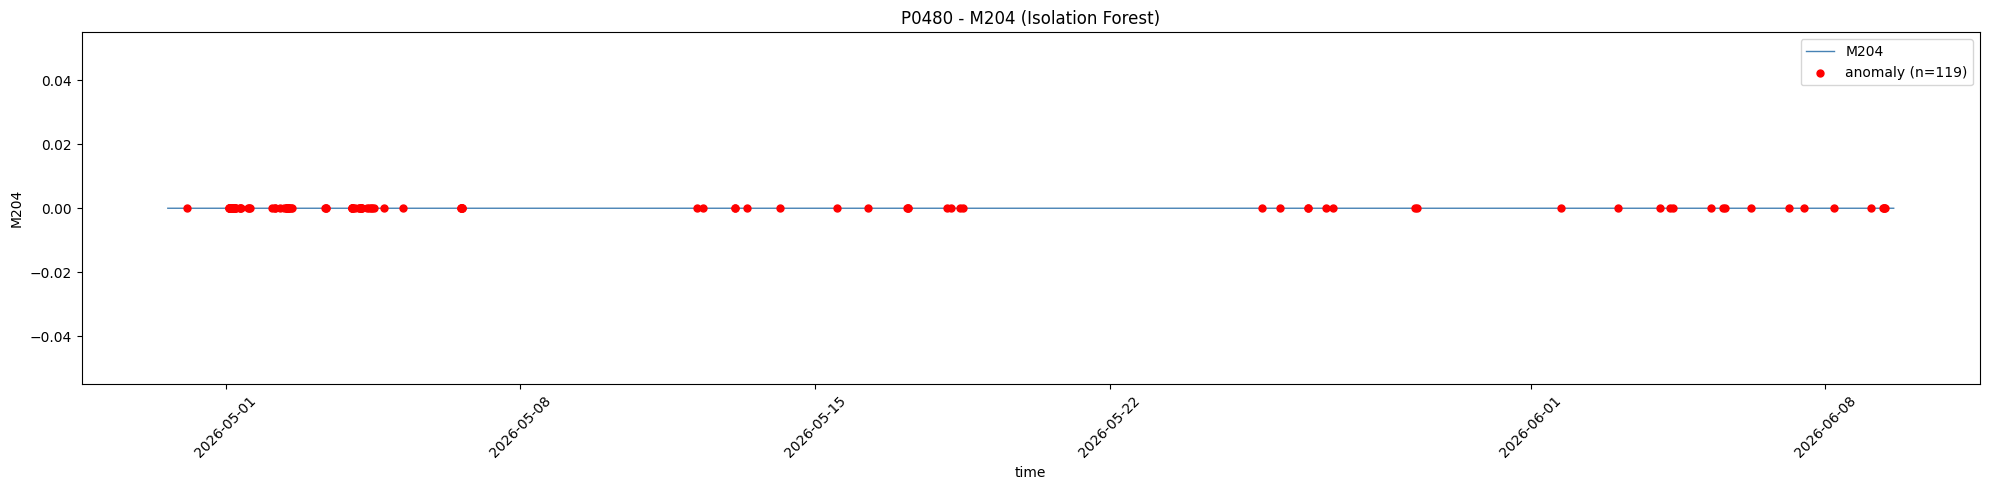

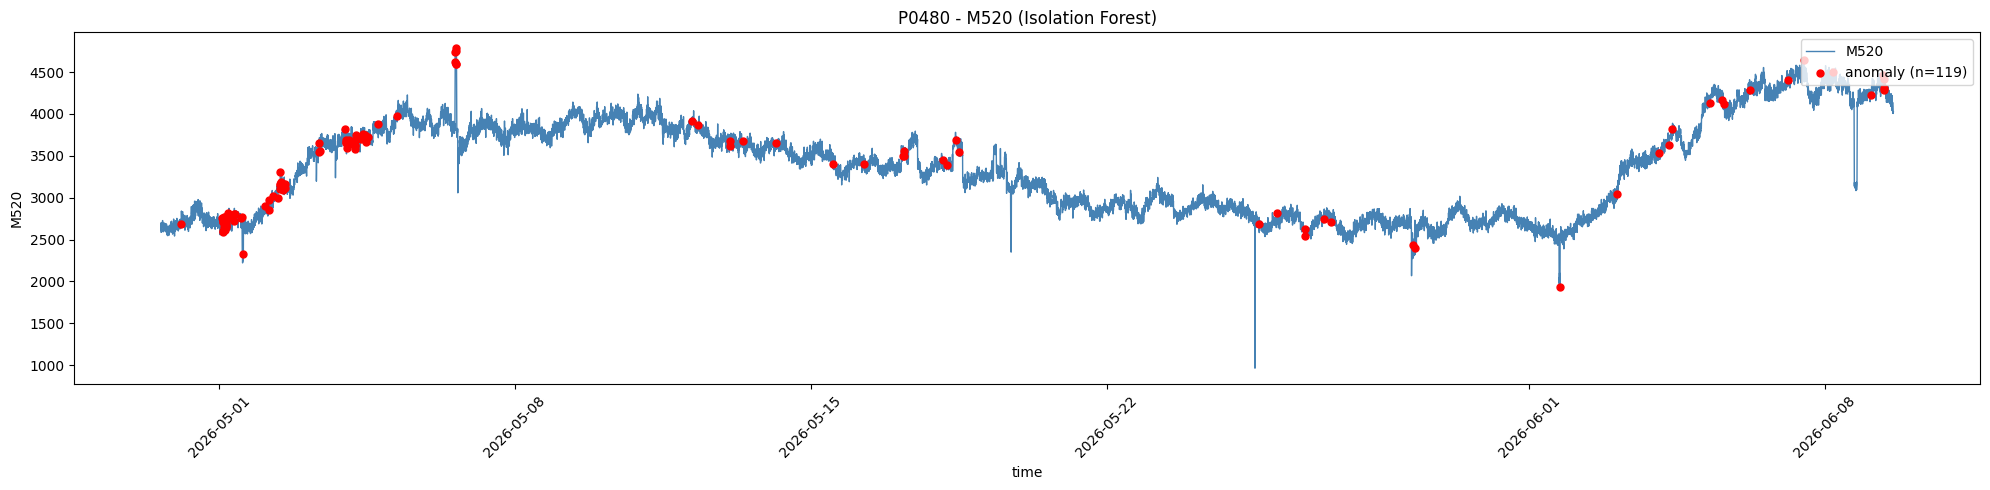

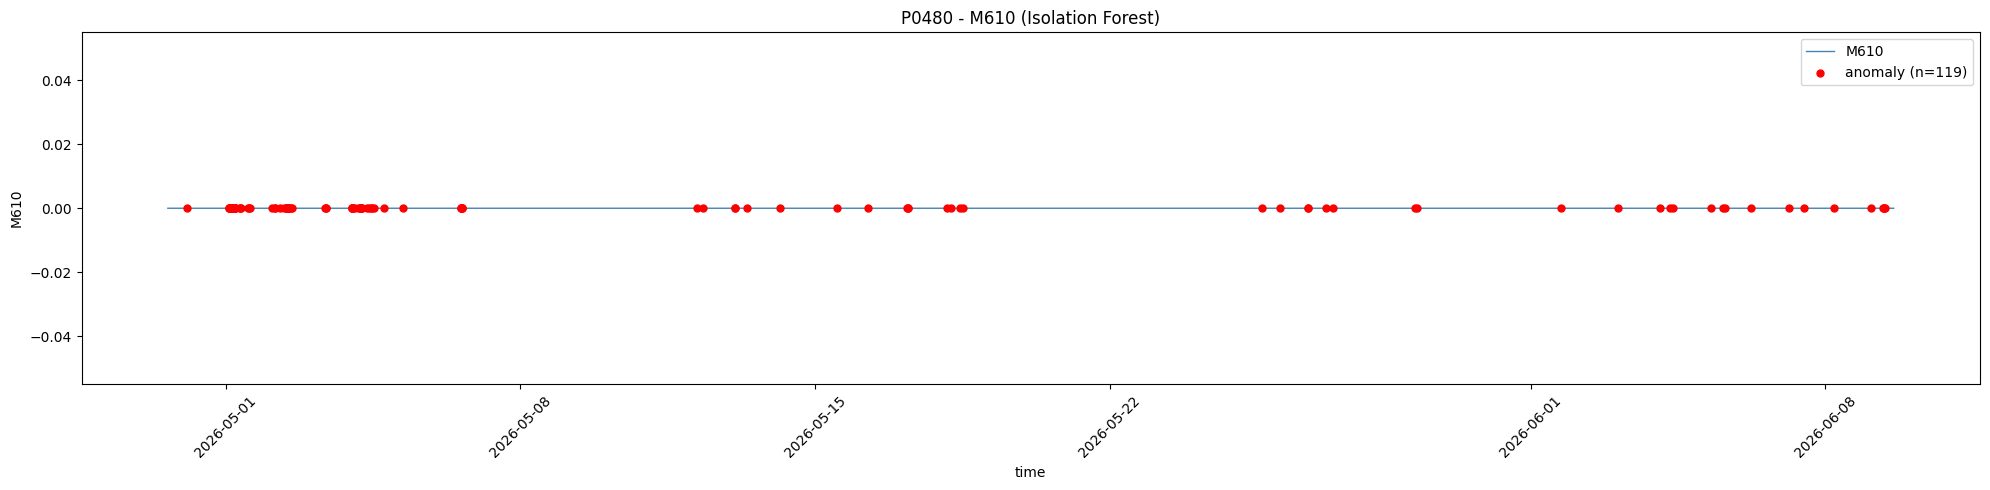

In [16]:
metrics_with_anomalies = anomaly_summary.loc[
    anomaly_summary["anomaly_count"] > 0, "metric"
].tolist()

print(f"anomaly가 있는 메트릭 수: {len(metrics_with_anomalies)}")

for col in metrics_with_anomalies:
    fig, ax = plt.subplots(figsize=(20, 5))

    ax.plot(df["time"], df[col], color="steelblue", linewidth=1.0, label=col)

    idx = df.index[anomaly_mask[col]]
    ax.scatter(
        df.loc[idx, "time"],
        df.loc[idx, col],
        color="red",
        s=25,
        zorder=5,
        label=f"anomaly (n={anomaly_mask[col].sum()})",
    )

    ax.set_title(f"{TARGET_PLMN} - {col} (Isolation Forest)")
    ax.set_xlabel("time")
    ax.set_ylabel(col)
    ax.legend(loc="upper right")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 5. 시점별 anomaly 발생 빈도

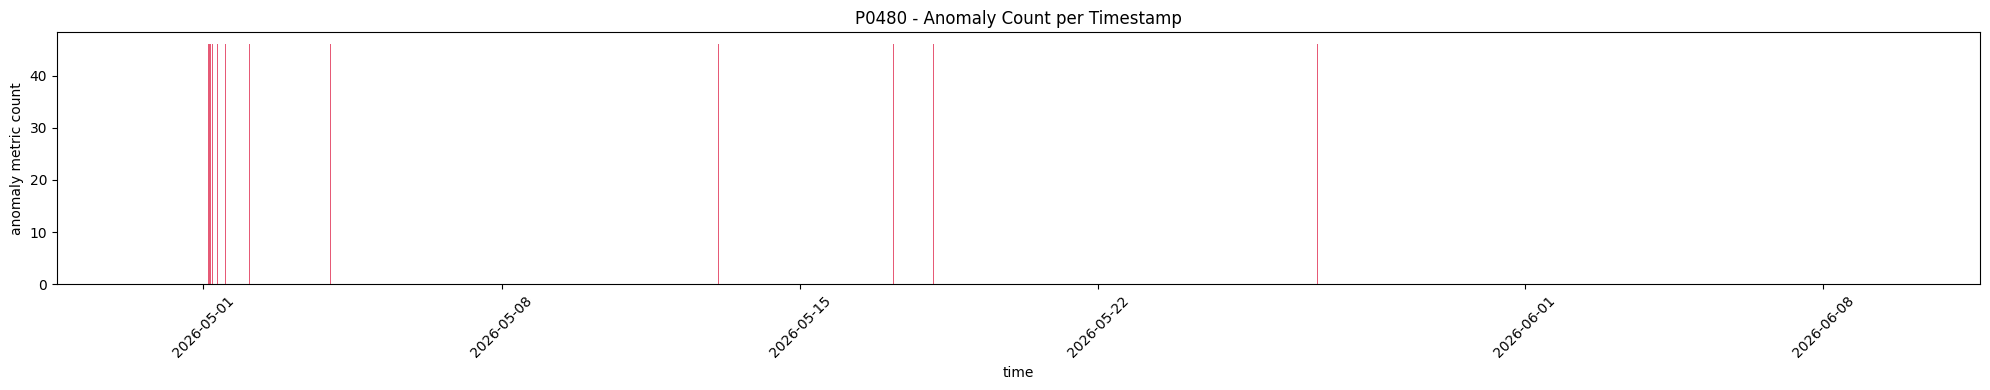

In [17]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.bar(df["time"], df["anomaly_count"], width=0.003, color="crimson", alpha=0.7)
ax.set_title(f"{TARGET_PLMN} - Anomaly Count per Timestamp")
ax.set_xlabel("time")
ax.set_ylabel("anomaly metric count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Anomaly 상세 목록 (CSV 저장)

In [18]:
anomaly_rows = []

for col in metric_cols:
    idx = df.index[anomaly_mask[col]]
    for i in idx:
        anomaly_rows.append(
            {
                "time": df.loc[i, "time"],
                "metric": col,
                "value": df.loc[i, col],
                "if_score": df.loc[i, "if_score"],
            }
        )

anomaly_detail = (
    pd.DataFrame(anomaly_rows)
    .sort_values(["time", "metric"])
    .reset_index(drop=True)
)

os.makedirs(SAVE_DIR, exist_ok=True)
detail_csv_path = os.path.join(SAVE_DIR, f"{TARGET_PLMN}_isolation_forest_anomalies.csv")
anomaly_detail.to_csv(detail_csv_path, index=False)

timestamp_summary = (
    df.loc[df["is_anomaly"], ["time", "if_score", "anomaly_count"]]
    .sort_values("time")
    .reset_index(drop=True)
)
summary_csv_path = os.path.join(SAVE_DIR, f"{TARGET_PLMN}_isolation_forest_timestamps.csv")
timestamp_summary.to_csv(summary_csv_path, index=False)

print(f"총 anomaly 레코드: {len(anomaly_detail):,}")
print(f"anomaly 시점 수: {len(timestamp_summary):,}")
print(f"저장: {detail_csv_path}")
print(f"저장: {summary_csv_path}")
anomaly_detail.head(20)

총 anomaly 레코드: 5,474
anomaly 시점 수: 119
저장: ../results/P0480_isolation_forest_anomalies.csv
저장: ../results/P0480_isolation_forest_timestamps.csv


,time,metric,value,if_score
0,2026-04-30 02:10:00+00:00,M029,0.0,-0.015017
1,2026-04-30 02:10:00+00:00,M037,0.0,-0.015017
2,2026-04-30 02:10:00+00:00,M104,0.0,-0.015017
3,2026-04-30 02:10:00+00:00,M162,0.0,-0.015017
4,2026-04-30 02:10:00+00:00,M164,0.0,-0.015017
5,2026-04-30 02:10:00+00:00,M185,51.0,-0.015017
6,2026-04-30 02:10:00+00:00,M204,0.0,-0.015017
7,2026-04-30 02:10:00+00:00,M238,0.0,-0.015017
8,2026-04-30 02:10:00+00:00,M265,13.0,-0.015017
9,2026-04-30 02:10:00+00:00,M318,0.0,-0.015017
